# Project Introduction

This notebook performs profitability analysis using only the cleaned datasets in `data/processed/`. It does not reuse unsupported assumptions from prior reference notebooks.

The analysis is built directly from available revenue, cost, profit, customer, product/category, region, and channel columns.
        

In [1]:
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 180

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
)
logger = logging.getLogger("profitability_analysis")


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "processed").exists():
            return candidate
    return start


def ensure_directory(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"

ensure_directory(OUTPUT_DIR)
ensure_directory(FIGURES_DIR)

logger.info("Project root: %s", PROJECT_ROOT)
logger.info("Processed data path: %s", DATA_DIR)
logger.info("Output path: %s", OUTPUT_DIR)
logger.info("Figure path: %s", FIGURES_DIR)

print("Environment setup complete.")
        

2026-07-11 12:47:13,175 - INFO - Project root: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics
2026-07-11 12:47:13,175 - INFO - Processed data path: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/data/processed
2026-07-11 12:47:13,175 - INFO - Output path: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs
2026-07-11 12:47:13,175 - INFO - Figure path: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/figures


Environment setup complete.


## Business Problem

The goal is to identify where revenue and profit are concentrated, which customers and categories contribute most to profitability, where losses exist, and what practical actions can improve financial performance.
        

## Load Processed Dataset

This section loads all cleaned datasets and validates file presence before analysis.
        

In [2]:
def load_dataset(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing required dataset: {path}")
    df = pd.read_csv(path)
    logger.info("Loaded %s with shape %s", path.name, df.shape)
    return df


try:
    customers = load_dataset(DATA_DIR / "financial_customers_clean.csv")
    transactions = load_dataset(DATA_DIR / "financial_transactions_clean.csv")
    monthly_revenue = load_dataset(DATA_DIR / "monthly_revenue_clean.csv")
except Exception as exc:
    logger.exception("Dataset loading failed")
    raise exc

print("Customers columns:", customers.columns.tolist())
print("Transactions columns:", transactions.columns.tolist())
print("Monthly revenue columns:", monthly_revenue.columns.tolist())
        

2026-07-11 12:47:13,247 - INFO - Loaded financial_customers_clean.csv with shape (20000, 36)
2026-07-11 12:47:14,000 - INFO - Loaded financial_transactions_clean.csv with shape (329202, 30)
2026-07-11 12:47:14,004 - INFO - Loaded monthly_revenue_clean.csv with shape (36, 18)


Customers columns: ['customer_id', 'signup_date', 'customer_age', 'country', 'region', 'city', 'industry', 'company_size', 'subscription_plan', 'contract_type', 'contract_length_months', 'monthly_recurring_revenue', 'payment_method', 'support_tickets', 'usage_score', 'login_frequency', 'nps_score', 'discount_percentage', 'tenure_months', 'customer_segment', 'customer_lifetime_value', 'customer_acquisition_cost', 'acquisition_channel', 'acquisition_month', 'is_active', 'churn', 'last_transaction_date', 'days_since_last_transaction', 'frequency_score', 'monetary_score', 'average_transaction_value', 'total_transactions', 'total_revenue', 'total_profit', 'customer_profitability', 'risk_score']
Transactions columns: ['transaction_id', 'invoice_id', 'customer_id', 'transaction_date', 'billing_cycle', 'gross_amount', 'discount', 'tax', 'processing_fee', 'refund_amount', 'support_cost', 'marketing_cost', 'operational_cost', 'net_revenue', 'profit', 'profit_margin', 'payment_method', 'transacti

## Profitability Analysis Overview

### Column Mapping Used from the Datasets

- Revenue columns: `gross_amount`, `net_revenue`, `gross_revenue`, `monthly_recurring_revenue`, `total_revenue`
- Cost columns: `processing_fee`, `refund_amount`, `support_cost`, `marketing_cost`, `operational_cost`
- Profit columns: `profit`, `profit_margin`, `total_profit`
- Customer columns: `customer_id`, `customer_segment`, `country`, `region`, `acquisition_channel`, `subscription_plan`, `customer_profitability`
- Product / category columns: `transaction_category`, `subscription_plan`
- Channel columns: `revenue_source`, `acquisition_channel`

### Assumptions for Derived Metrics

- If a cost field is missing at transaction level, it is treated as `0` in total cost calculation.
- Derived transaction total cost is computed as:
  `processing_fee + refund_amount + support_cost + marketing_cost + operational_cost`
- If transaction-level `profit` is missing, it is derived as:
  `net_revenue - derived_total_cost`
- If transaction-level `profit_margin` is missing, it is derived as:
  `profit / net_revenue` with safe division.
        

## Data Preparation

This section standardizes date fields, prepares derived cost/profit metrics, and creates reusable analytical tables.
        

In [3]:
def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    numerator_series = pd.Series(numerator)
    denominator_series = pd.Series(denominator)
    values = np.divide(
        numerator_series.astype(float),
        denominator_series.astype(float),
        out=np.zeros(len(numerator_series), dtype=float),
        where=denominator_series.astype(float) != 0,
    )
    return pd.Series(values, index=numerator_series.index)


def prepare_transactions(df: pd.DataFrame) -> pd.DataFrame:
    work_df = df.copy()
    work_df["transaction_date"] = pd.to_datetime(
        work_df["transaction_date"], errors="coerce"
    )

    cost_columns = [
        "processing_fee",
        "refund_amount",
        "support_cost",
        "marketing_cost",
        "operational_cost",
    ]
    for col in cost_columns:
        if col not in work_df.columns:
            work_df[col] = 0.0
        work_df[col] = pd.to_numeric(work_df[col], errors="coerce").fillna(0.0)

    work_df["derived_total_cost"] = work_df[cost_columns].sum(axis=1)

    if "net_revenue" not in work_df.columns:
        if "gross_amount" in work_df.columns and "discount" in work_df.columns:
            work_df["net_revenue"] = (
                pd.to_numeric(work_df["gross_amount"], errors="coerce").fillna(0)
                - pd.to_numeric(work_df["discount"], errors="coerce").fillna(0)
            )
        else:
            raise ValueError("No usable revenue column found in transactions dataset.")

    work_df["net_revenue"] = pd.to_numeric(
        work_df["net_revenue"], errors="coerce"
    ).fillna(0.0)

    if "profit" not in work_df.columns:
        work_df["profit"] = work_df["net_revenue"] - work_df["derived_total_cost"]
    work_df["profit"] = pd.to_numeric(work_df["profit"], errors="coerce").fillna(
        work_df["net_revenue"] - work_df["derived_total_cost"]
    )

    derived_margin = safe_divide(work_df["profit"], work_df["net_revenue"])
    if "profit_margin" not in work_df.columns:
        work_df["profit_margin"] = derived_margin
    work_df["profit_margin"] = pd.to_numeric(
        work_df["profit_margin"], errors="coerce"
    )
    work_df["profit_margin"] = work_df["profit_margin"].fillna(derived_margin)

    return work_df


def prepare_customers(df: pd.DataFrame) -> pd.DataFrame:
    work_df = df.copy()
    date_cols = ["signup_date", "last_transaction_date"]
    for col in date_cols:
        if col in work_df.columns:
            work_df[col] = pd.to_datetime(work_df[col], errors="coerce")
    return work_df


transactions_prepared = prepare_transactions(transactions)
customers_prepared = prepare_customers(customers)

print("Prepared transactions shape:", transactions_prepared.shape)
print("Prepared customers shape:", customers_prepared.shape)
print("Derived cost total:", round(transactions_prepared["derived_total_cost"].sum(), 2))

Prepared transactions shape: (329202, 31)
Prepared customers shape: (20000, 36)
Derived cost total: 100864711.74


## Revenue Analysis

Revenue is analyzed from transaction-level net revenue and monthly aggregate revenue.

In [4]:
revenue_analysis = pd.DataFrame(
    {
        "metric": [
            "total_transaction_revenue",
            "average_transaction_revenue",
            "median_transaction_revenue",
            "monthly_table_total_net_revenue",
        ],
        "value": [
            transactions_prepared["net_revenue"].sum(),
            transactions_prepared["net_revenue"].mean(),
            transactions_prepared["net_revenue"].median(),
            monthly_revenue["net_revenue"].sum(),
        ],
    }
)

revenue_analysis.to_csv(OUTPUT_DIR / "revenue_analysis.csv", index=False)
print(revenue_analysis.to_string(index=False))

                         metric        value
      total_transaction_revenue 5.303375e+08
    average_transaction_revenue 1.610979e+03
     median_transaction_revenue 2.283050e+02
monthly_table_total_net_revenue 5.297543e+08


## Cost Analysis (if available)

Cost analysis uses available transaction-level cost columns. Missing cost columns are defaulted to `0` as documented in the assumptions.

    cost_component   total_cost
    processing_fee  13704356.69
     refund_amount   9412266.83
      support_cost   3212483.62
    marketing_cost  27769528.90
  operational_cost  46766075.70
derived_total_cost 100864711.74


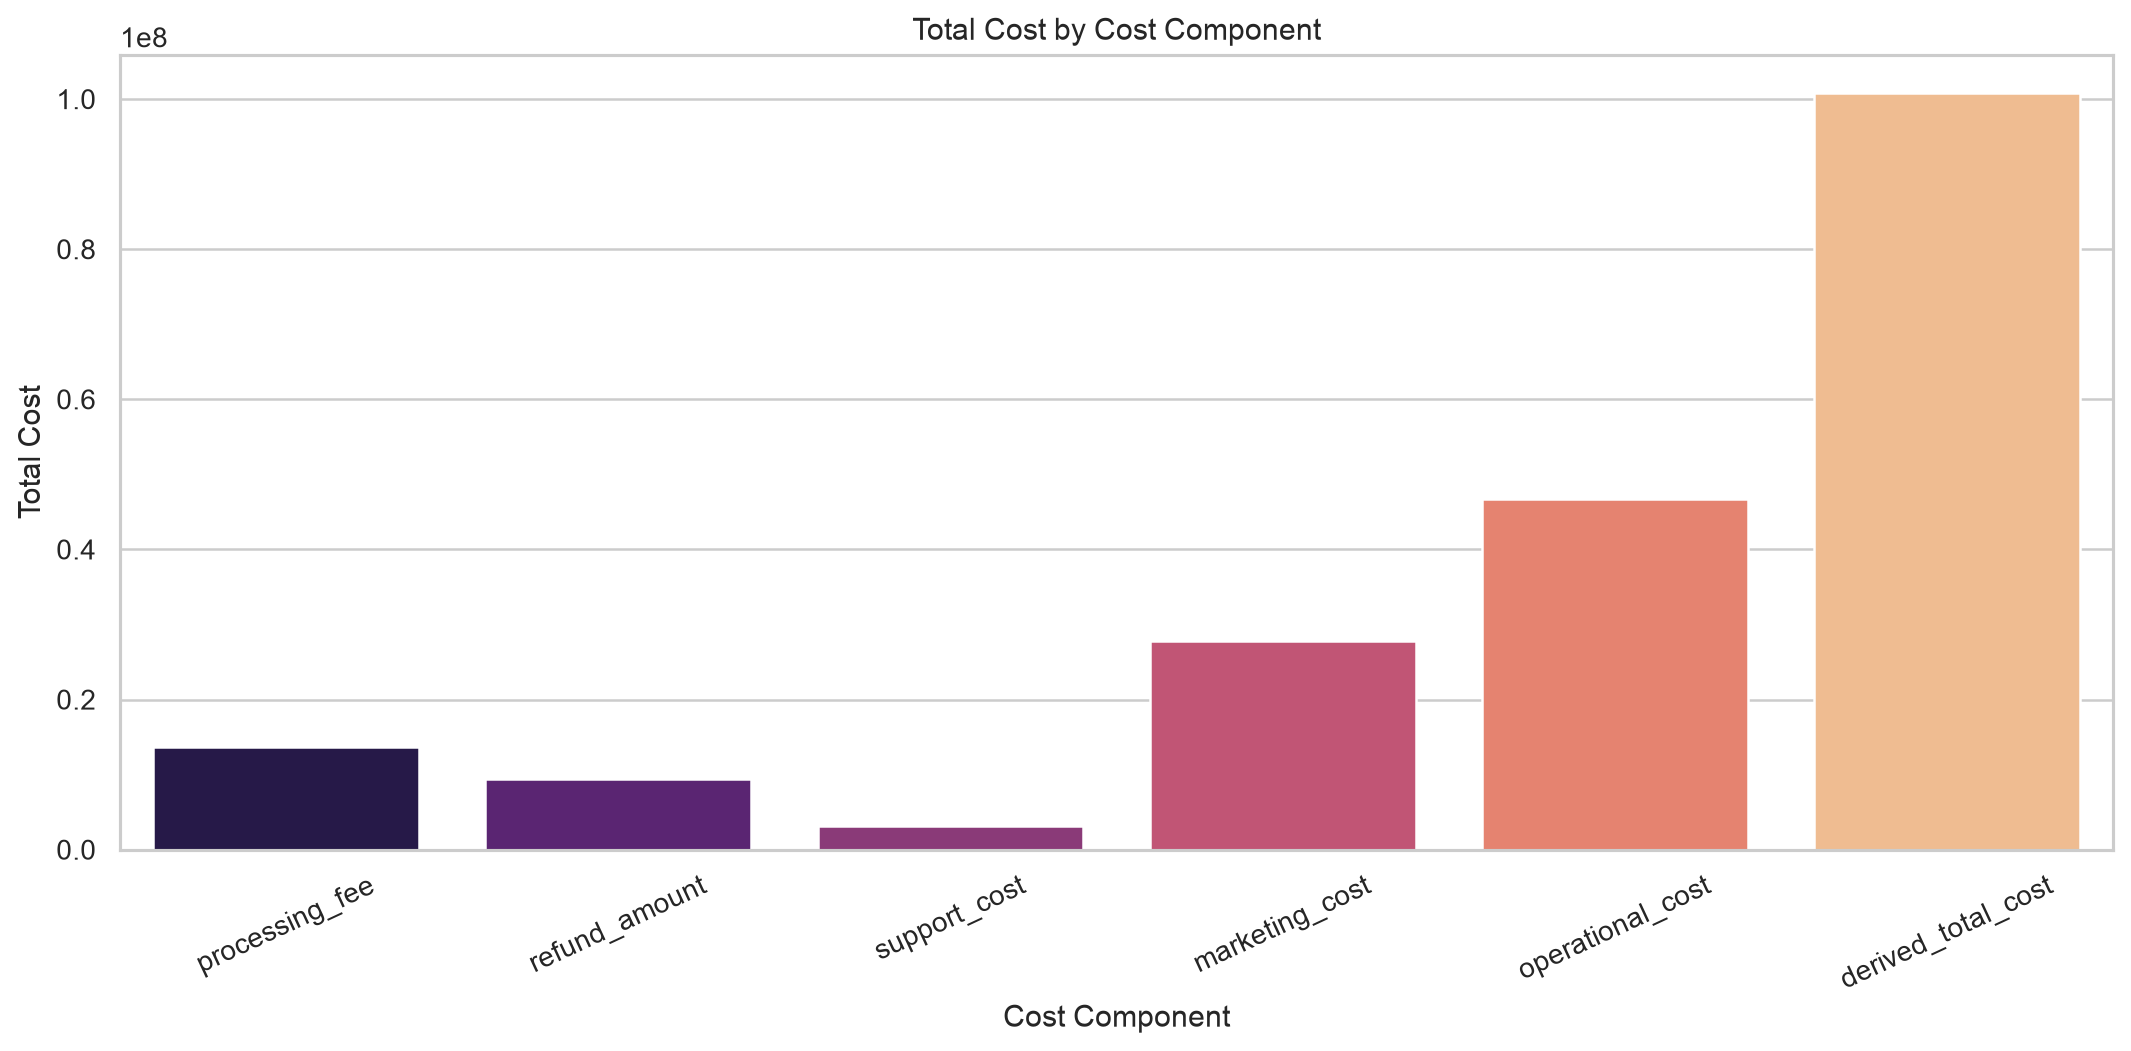

Business insight: marketing and operational costs are major cost drivers and should be optimized first.


In [5]:
cost_breakdown = transactions_prepared[
    [
        "processing_fee",
        "refund_amount",
        "support_cost",
        "marketing_cost",
        "operational_cost",
        "derived_total_cost",
    ]
].sum().to_frame("total_cost").reset_index().rename(columns={"index": "cost_component"})

print(cost_breakdown.to_string(index=False))

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.barplot(data=cost_breakdown, x="cost_component", y="total_cost", palette="magma", ax=ax)
ax.set_title("Total Cost by Cost Component")
ax.set_xlabel("Cost Component")
ax.set_ylabel("Total Cost")
ax.tick_params(axis="x", rotation=25)

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "cost_breakdown.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: marketing and operational costs are major cost drivers and should be optimized first.")

## Profit Calculation

Profitability totals are computed from prepared transaction-level values.

In [6]:
profitability_summary = pd.DataFrame(
    {
        "metric": [
            "total_revenue",
            "total_cost",
            "total_profit",
            "average_profit_per_transaction",
        ],
        "value": [
            transactions_prepared["net_revenue"].sum(),
            transactions_prepared["derived_total_cost"].sum(),
            transactions_prepared["profit"].sum(),
            transactions_prepared["profit"].mean(),
        ],
    }
)

profitability_summary.to_csv(OUTPUT_DIR / "profitability_summary.csv", index=False)
print(profitability_summary.to_string(index=False))

                        metric        value
                 total_revenue 5.303375e+08
                    total_cost 1.008647e+08
                  total_profit 4.388851e+08
average_profit_per_transaction 1.333179e+03


## Profit Margin Analysis

Profit margin is reviewed at transaction level and monthly aggregate level.

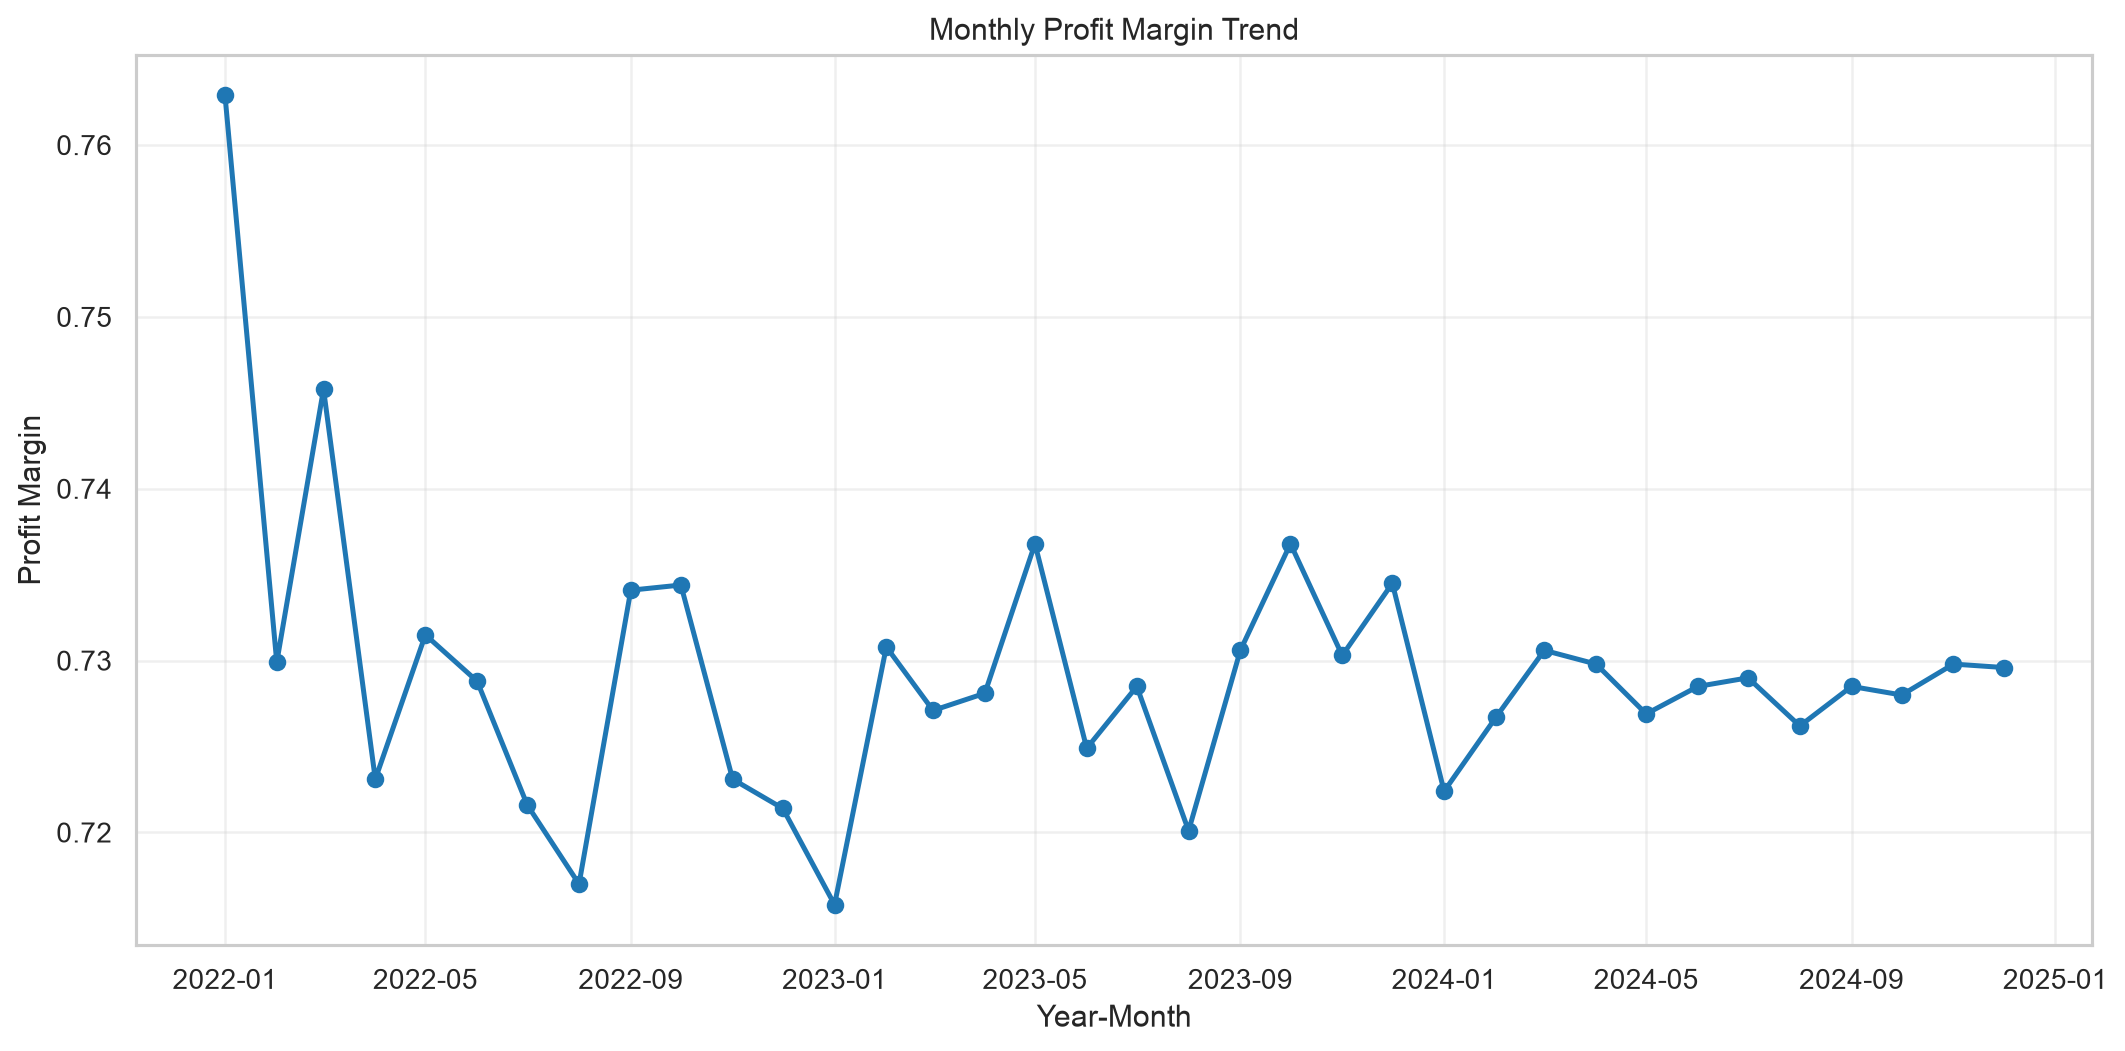

Business insight: average transaction profit margin is 65.44%, indicating overall profitability quality.


In [7]:
avg_margin = float(transactions_prepared["profit_margin"].mean())
monthly_margin = monthly_revenue[["year_month", "profit_margin"]].copy()
monthly_margin["year_month"] = pd.to_datetime(monthly_margin["year_month"], errors="coerce")

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
ax.plot(monthly_margin["year_month"], monthly_margin["profit_margin"], marker="o", linewidth=2, color="#1f77b4")
ax.set_title("Monthly Profit Margin Trend")
ax.set_xlabel("Year-Month")
ax.set_ylabel("Profit Margin")
ax.grid(True, alpha=0.3)

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "monthly_profit_margin_trend.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print(f"Business insight: average transaction profit margin is {avg_margin:.2%}, indicating overall profitability quality.")

## Revenue Distribution

Distribution analysis highlights the spread and skew of transaction-level revenue.

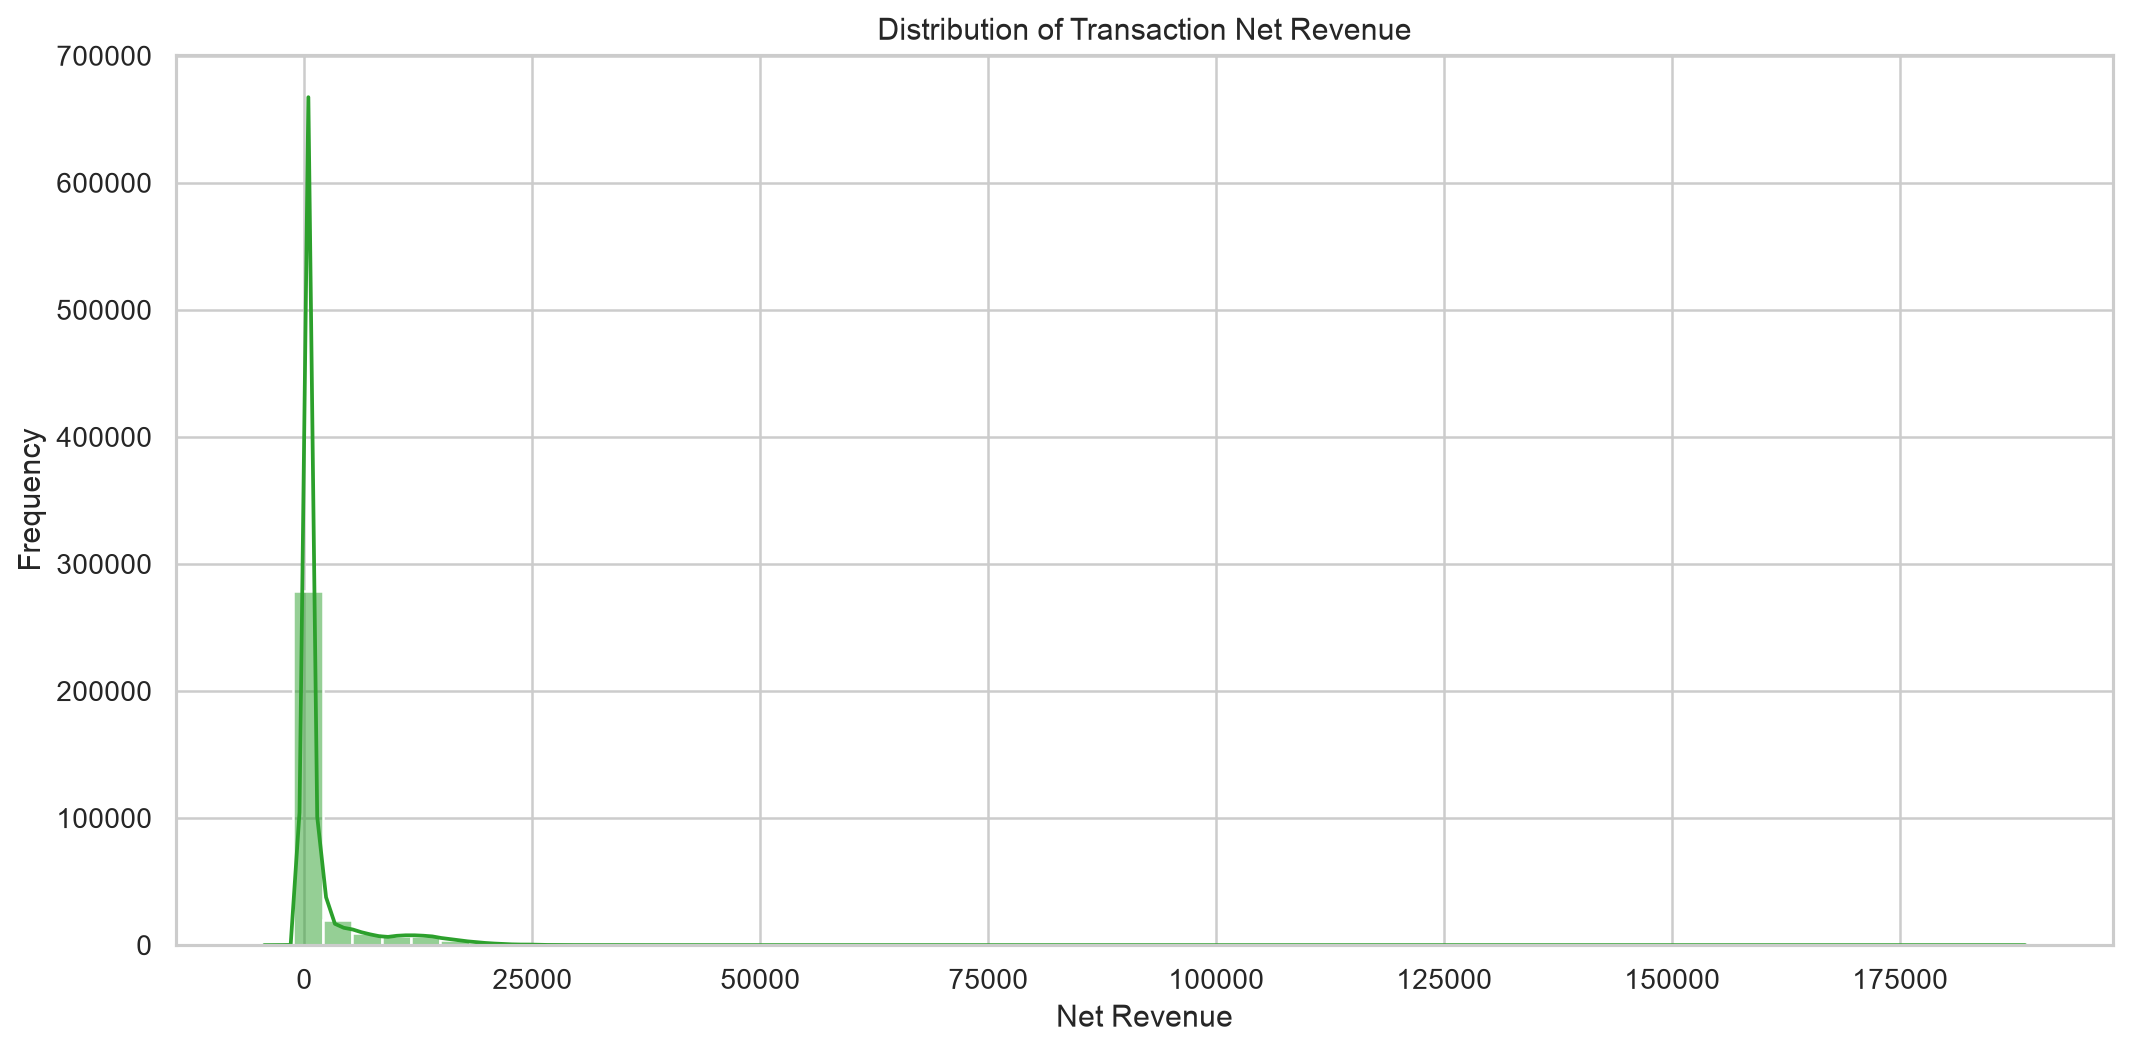

Business insight: the revenue distribution is right-skewed, meaning a smaller number of high-value transactions drive a large revenue share.


In [8]:
# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.histplot(transactions_prepared["net_revenue"], bins=60, kde=True, color="#2ca02c", ax=ax)
ax.set_title("Distribution of Transaction Net Revenue")
ax.set_xlabel("Net Revenue")
ax.set_ylabel("Frequency")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "revenue_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: the revenue distribution is right-skewed, meaning a smaller number of high-value transactions drive a large revenue share.")

## Customer Profitability Analysis

Customer profitability is computed from transaction-level aggregation and joined with customer attributes.

In [9]:
customer_profitability = (
    transactions_prepared.groupby("customer_id", as_index=False)
    .agg(
        customer_revenue=("net_revenue", "sum"),
        customer_profit=("profit", "sum"),
        customer_cost=("derived_total_cost", "sum"),
        transaction_count=("transaction_id", "nunique"),
    )
)
customer_profitability["customer_profit_margin"] = safe_divide(
    customer_profitability["customer_profit"], customer_profitability["customer_revenue"]
)

customer_attrs = customers_prepared[
    [
        "customer_id",
        "country",
        "region",
        "customer_segment",
        "acquisition_channel",
        "subscription_plan",
    ]
].copy()

customer_profitability = customer_profitability.merge(
    customer_attrs, on="customer_id", how="left"
)
customer_profitability.to_csv(OUTPUT_DIR / "customer_profitability.csv", index=False)

print(customer_profitability.head(10).to_string(index=False))

customer_id  customer_revenue  customer_profit  customer_cost  transaction_count  customer_profit_margin   country        region customer_segment acquisition_channel subscription_plan
CUST_000000         122960.01        106865.55       16094.46                 16                0.869108   Germany        Europe             Core      Outbound Sales        Enterprise
CUST_000001           2847.75          2148.67         855.51                 18                0.754515     India          APAC New / Onboarding      Organic Search      Professional
CUST_000002           1160.09           788.05         435.29                 16                0.679301        UK        Europe             Core   Content Marketing             Basic
CUST_000003           4090.32          3214.71        1062.53                 16                0.785931       USA North America             Core      Outbound Sales      Professional
CUST_000004           2467.93          1915.44         552.49                 12

## Product / Category Profitability

`transaction_category` is used as the primary product/category dimension because it directly classifies revenue-generating transaction types.

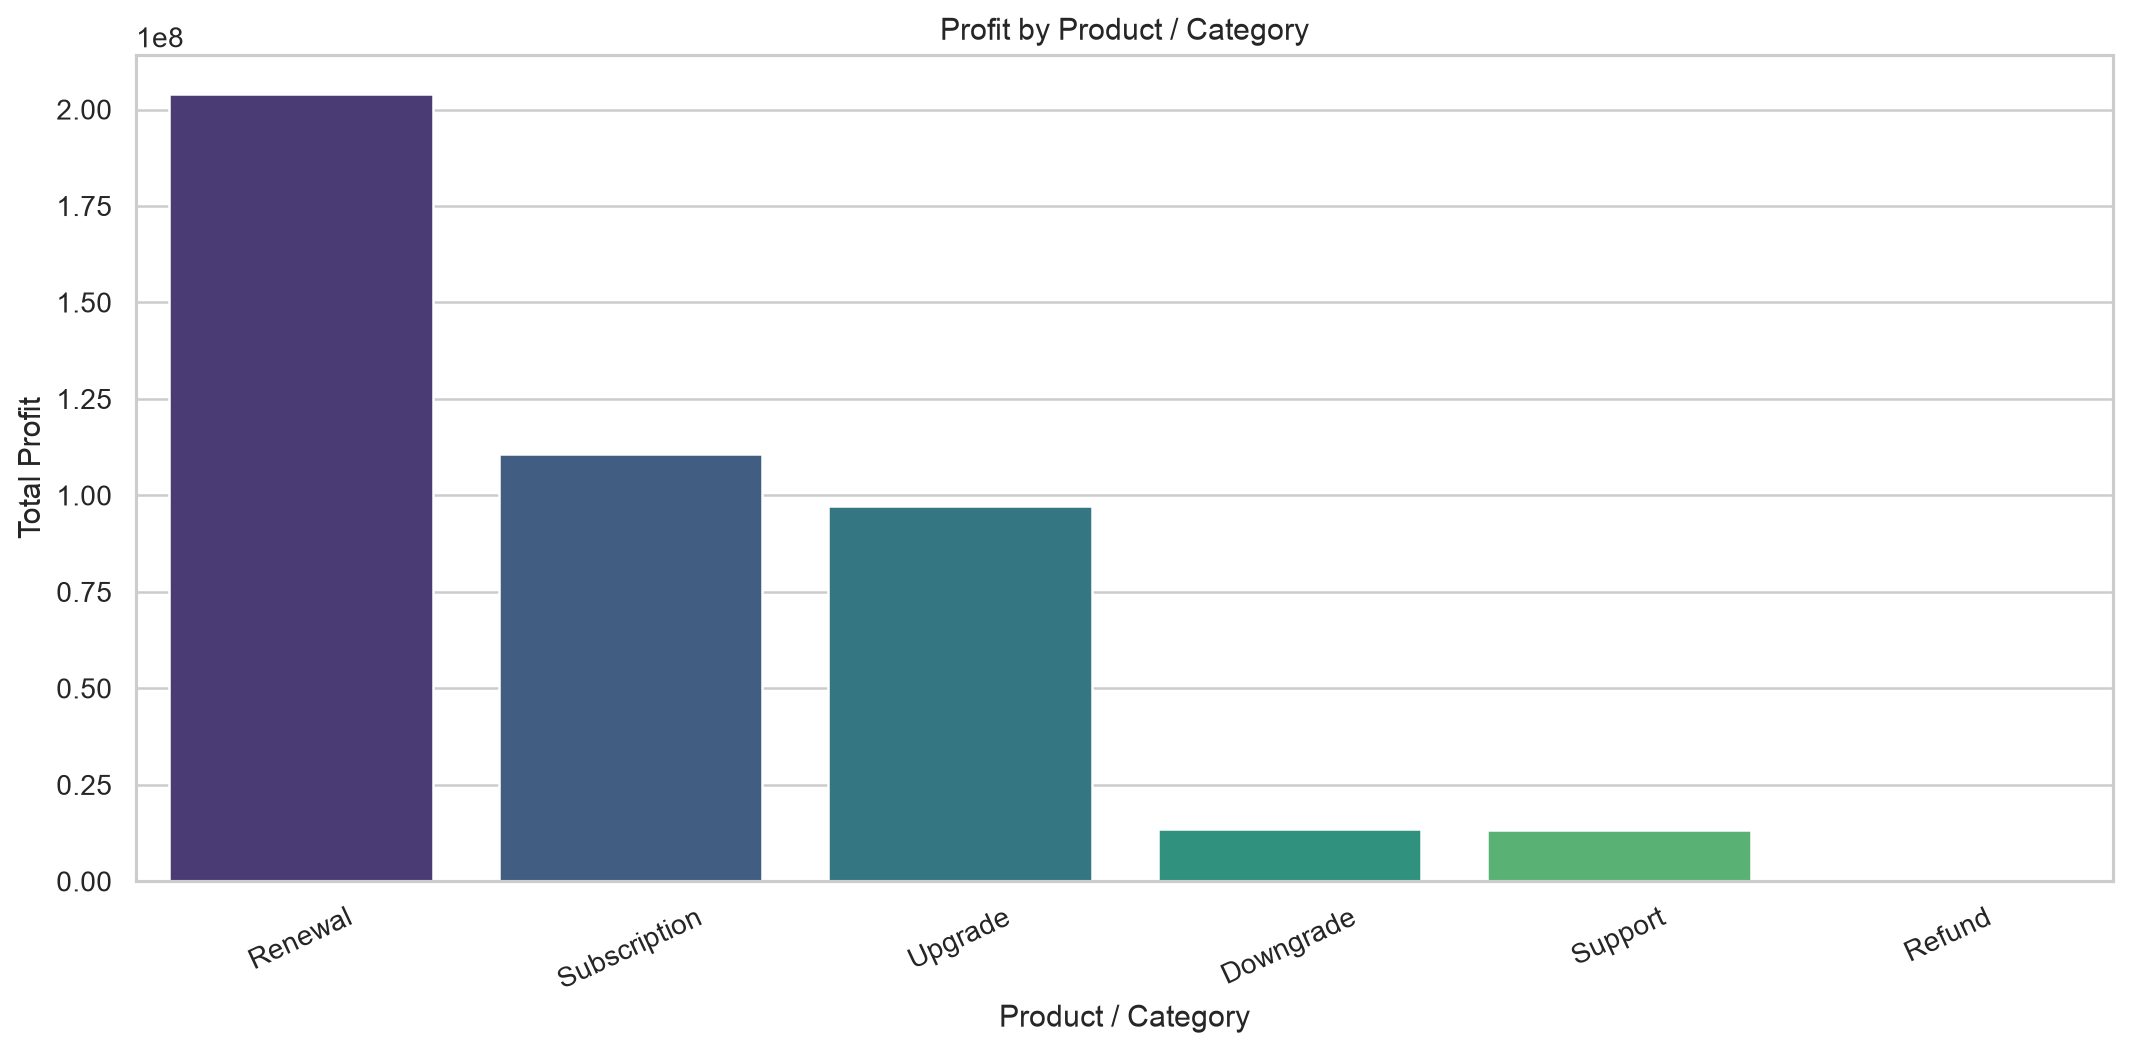

Business insight: category-level variance in profit reveals which offerings should be expanded or re-priced.


In [10]:
category_col = "transaction_category" if "transaction_category" in transactions_prepared.columns else "billing_cycle"

product_profitability = (
    transactions_prepared.groupby(category_col, as_index=False)
    .agg(
        total_revenue=("net_revenue", "sum"),
        total_profit=("profit", "sum"),
        total_cost=("derived_total_cost", "sum"),
        transaction_count=("transaction_id", "nunique"),
    )
)
product_profitability["profit_margin"] = safe_divide(
    product_profitability["total_profit"], product_profitability["total_revenue"]
)
product_profitability = product_profitability.sort_values("total_profit", ascending=False)
product_profitability.to_csv(OUTPUT_DIR / "product_profitability.csv", index=False)

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.barplot(data=product_profitability, x=category_col, y="total_profit", palette="viridis", ax=ax)
ax.set_title("Profit by Product / Category")
ax.set_xlabel("Product / Category")
ax.set_ylabel("Total Profit")
ax.tick_params(axis="x", rotation=25)

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "product_category_profitability.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: category-level variance in profit reveals which offerings should be expanded or re-priced.")

## Regional Profitability (if available)

Regional performance is analyzed using customer `region` and `country` attributes.

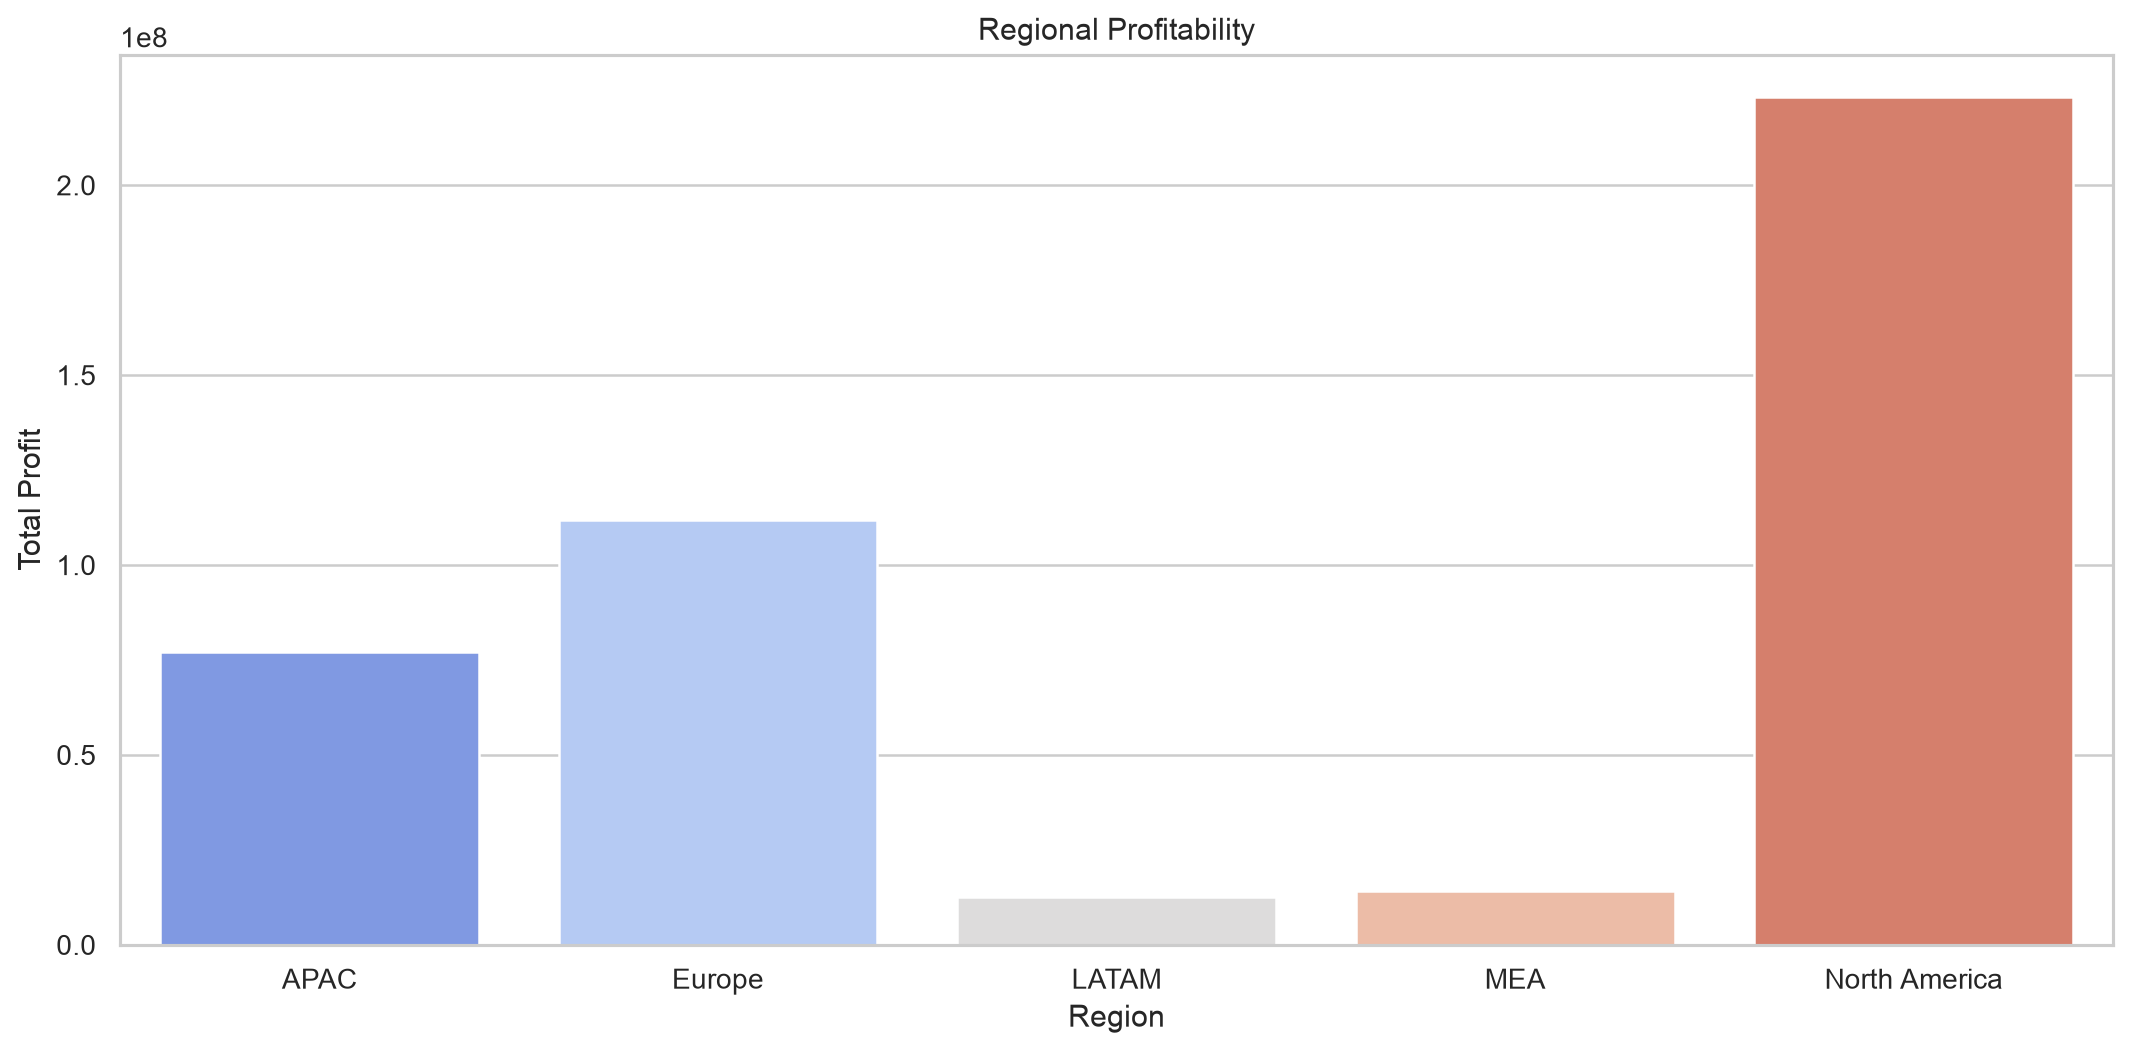

Business insight: regional profit gaps indicate where localized pricing or cost controls are needed.


In [11]:
if "region" in customer_profitability.columns:
    regional_profitability = (
        customer_profitability.groupby("region", as_index=False)
        .agg(total_revenue=("customer_revenue", "sum"), total_profit=("customer_profit", "sum"))
    )
    regional_profitability["profit_margin"] = safe_divide(
        regional_profitability["total_profit"], regional_profitability["total_revenue"]
    )

    # Create visualization
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot
    sns.barplot(data=regional_profitability, x="region", y="total_profit", palette="coolwarm", ax=ax)
    ax.set_title("Regional Profitability")
    ax.set_xlabel("Region")
    ax.set_ylabel("Total Profit")

    # Improve layout
    plt.tight_layout()

    # Save
    plt.savefig(
        FIGURES_DIR / "regional_profitability.png",
        dpi=300,
        bbox_inches="tight"
    )

    # Show inside notebook
    plt.show()

    print("Business insight: regional profit gaps indicate where localized pricing or cost controls are needed.")
else:
    regional_profitability = pd.DataFrame()
    print("Regional fields are not available; regional profitability section skipped.")

## Channel Profitability (if available)

For channel profitability, the analysis uses `revenue_source` in transactions as the primary channel field. If unavailable, `acquisition_channel` from customers is used as fallback.

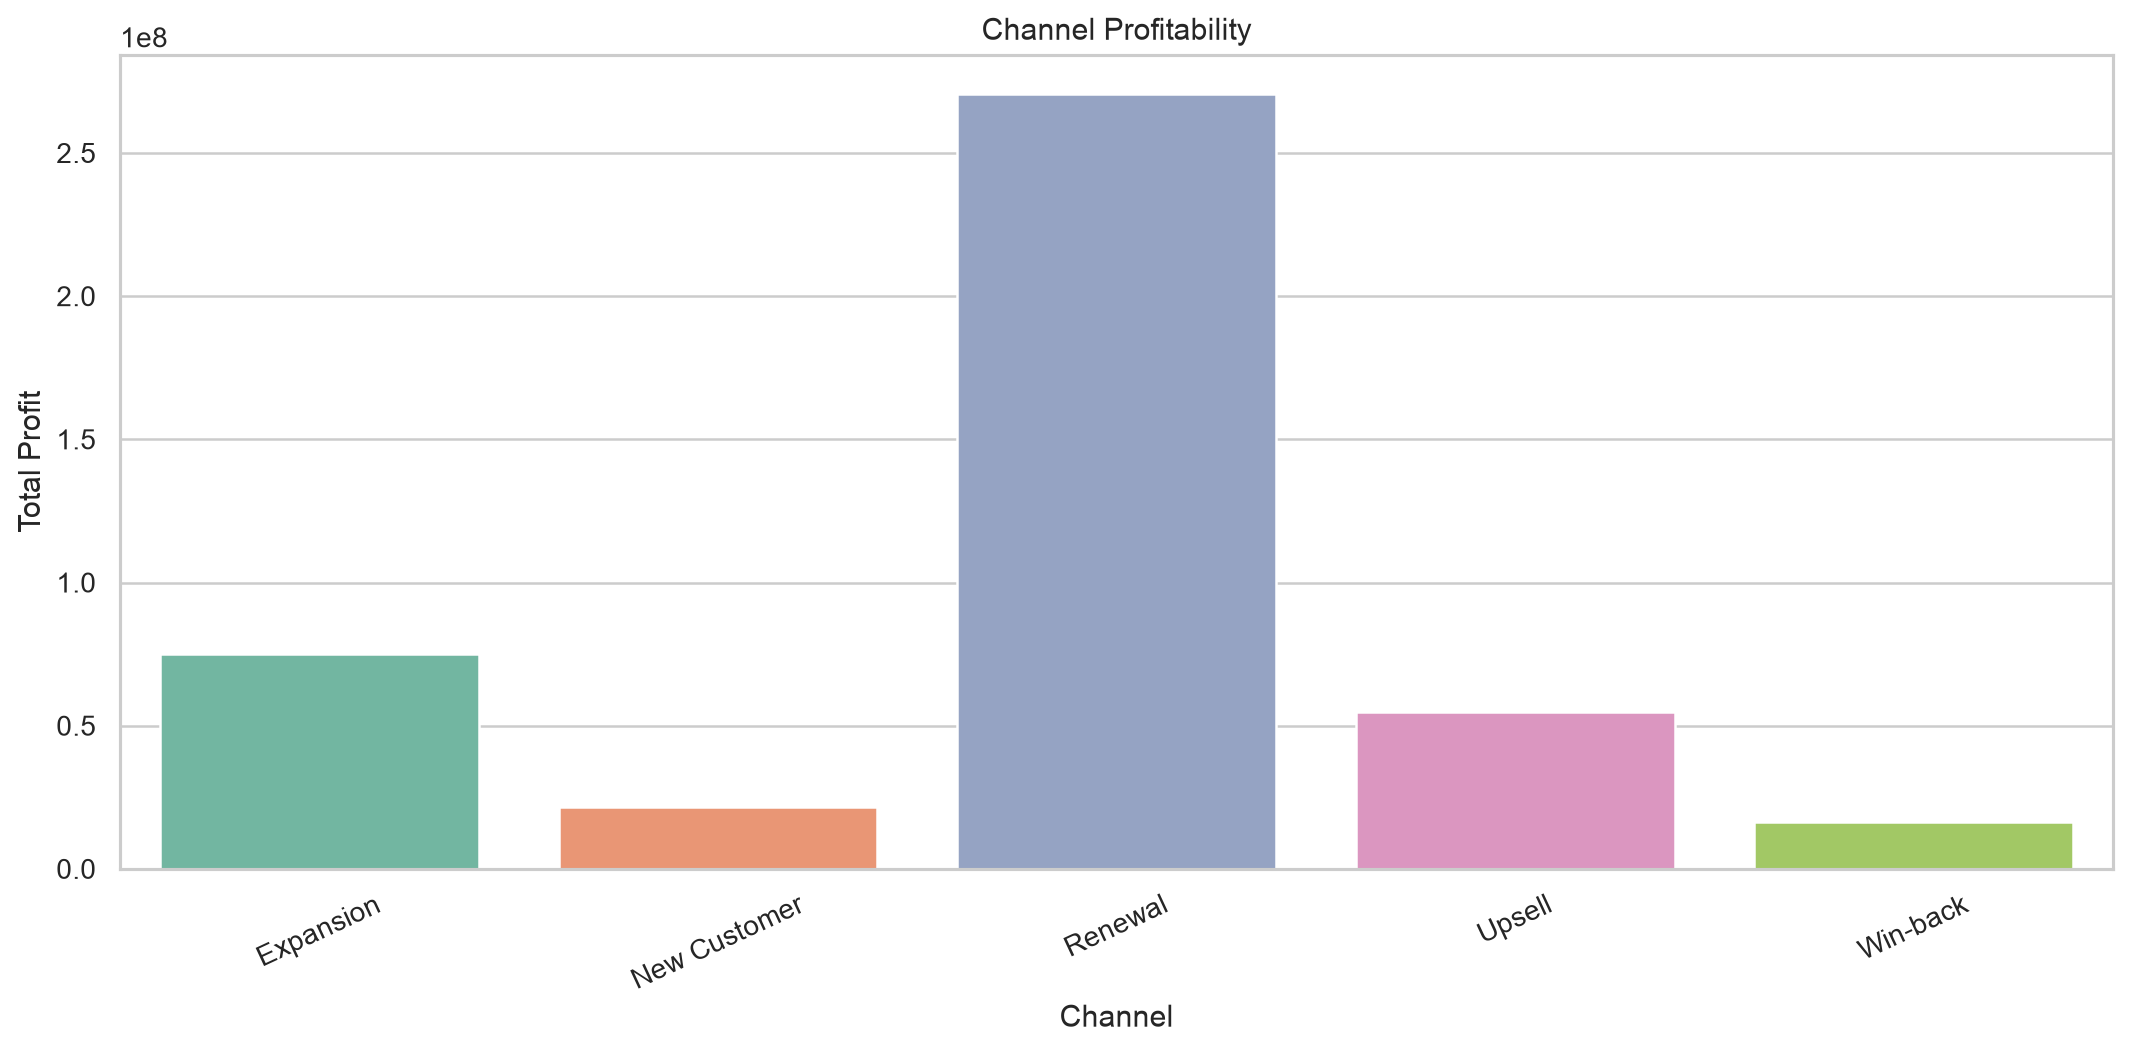

Business insight: channel-level profitability differences show where acquisition and retention spend should be reallocated.


In [12]:
if "revenue_source" in transactions_prepared.columns:
    channel_profitability = (
        transactions_prepared.groupby("revenue_source", as_index=False)
        .agg(total_revenue=("net_revenue", "sum"), total_profit=("profit", "sum"))
    )
    channel_name = "revenue_source"
elif "acquisition_channel" in customer_profitability.columns:
    channel_profitability = (
        customer_profitability.groupby("acquisition_channel", as_index=False)
        .agg(total_revenue=("customer_revenue", "sum"), total_profit=("customer_profit", "sum"))
    )
    channel_name = "acquisition_channel"
else:
    channel_profitability = pd.DataFrame()
    channel_name = "channel"

if not channel_profitability.empty:
    channel_profitability["profit_margin"] = safe_divide(
        channel_profitability["total_profit"], channel_profitability["total_revenue"]
    )

    # Create visualization
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot
    sns.barplot(data=channel_profitability, x=channel_name, y="total_profit", palette="Set2", ax=ax)
    ax.set_title("Channel Profitability")
    ax.set_xlabel("Channel")
    ax.set_ylabel("Total Profit")
    ax.tick_params(axis="x", rotation=25)

    # Improve layout
    plt.tight_layout()

    # Save
    plt.savefig(
        FIGURES_DIR / "channel_profitability.png",
        dpi=300,
        bbox_inches="tight"
    )

    # Show inside notebook
    plt.show()

    print("Business insight: channel-level profitability differences show where acquisition and retention spend should be reallocated.")
else:
    print("Channel fields are not available; channel profitability section skipped.")

## Customer Segment Profitability (if available)

Customer segment profitability is calculated from the `customer_segment` attribute when present.

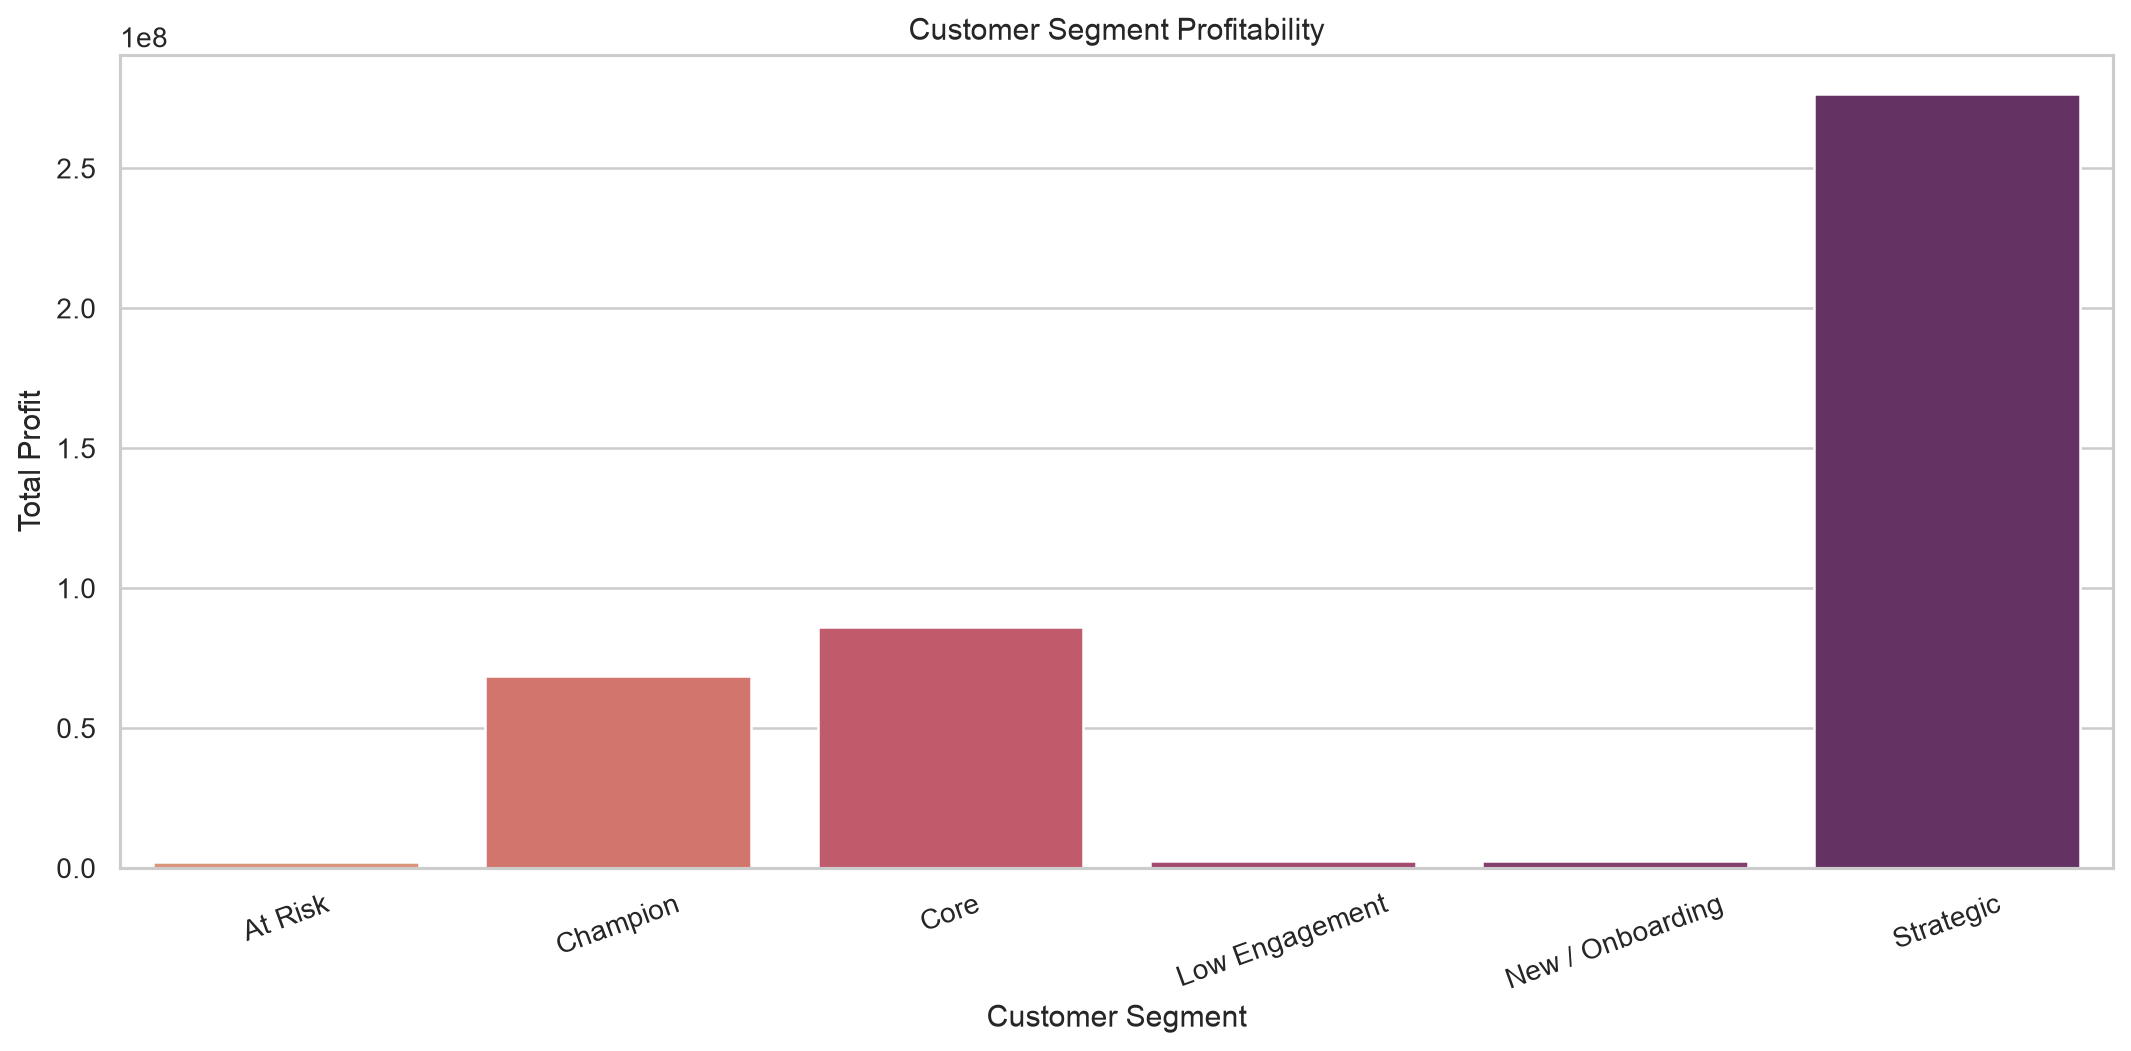

Business insight: segment-level profitability helps focus sales and success investments on high-margin customer groups.


In [13]:
if "customer_segment" in customer_profitability.columns:
    segment_profitability = (
        customer_profitability.groupby("customer_segment", as_index=False)
        .agg(
            total_revenue=("customer_revenue", "sum"),
            total_profit=("customer_profit", "sum"),
            customer_count=("customer_id", "nunique"),
        )
    )
    segment_profitability["profit_margin"] = safe_divide(
        segment_profitability["total_profit"], segment_profitability["total_revenue"]
    )

    # Create visualization
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot
    sns.barplot(data=segment_profitability, x="customer_segment", y="total_profit", palette="flare", ax=ax)
    ax.set_title("Customer Segment Profitability")
    ax.set_xlabel("Customer Segment")
    ax.set_ylabel("Total Profit")
    ax.tick_params(axis="x", rotation=20)

    # Improve layout
    plt.tight_layout()

    # Save
    plt.savefig(
        FIGURES_DIR / "customer_segment_profitability.png",
        dpi=300,
        bbox_inches="tight"
    )

    # Show inside notebook
    plt.show()

    print("Business insight: segment-level profitability helps focus sales and success investments on high-margin customer groups.")
else:
    segment_profitability = pd.DataFrame()
    print("Customer segment field is not available; segment profitability section skipped.")

## Top Revenue Contributors

Top customers by revenue contribution are identified to support account-level strategy.

customer_id  customer_revenue  customer_profit
CUST_010049         524421.10        446375.32
CUST_008236         486487.60        404932.13
CUST_001130         480131.02        426679.75
CUST_000464         474199.20        429864.43
CUST_010989         465373.52        412756.15
CUST_016480         459007.28        413022.85
CUST_000905         456061.63        373273.70
CUST_017723         447915.48        394971.31
CUST_017664         445894.17        375763.08
CUST_016321         445122.96        397431.81


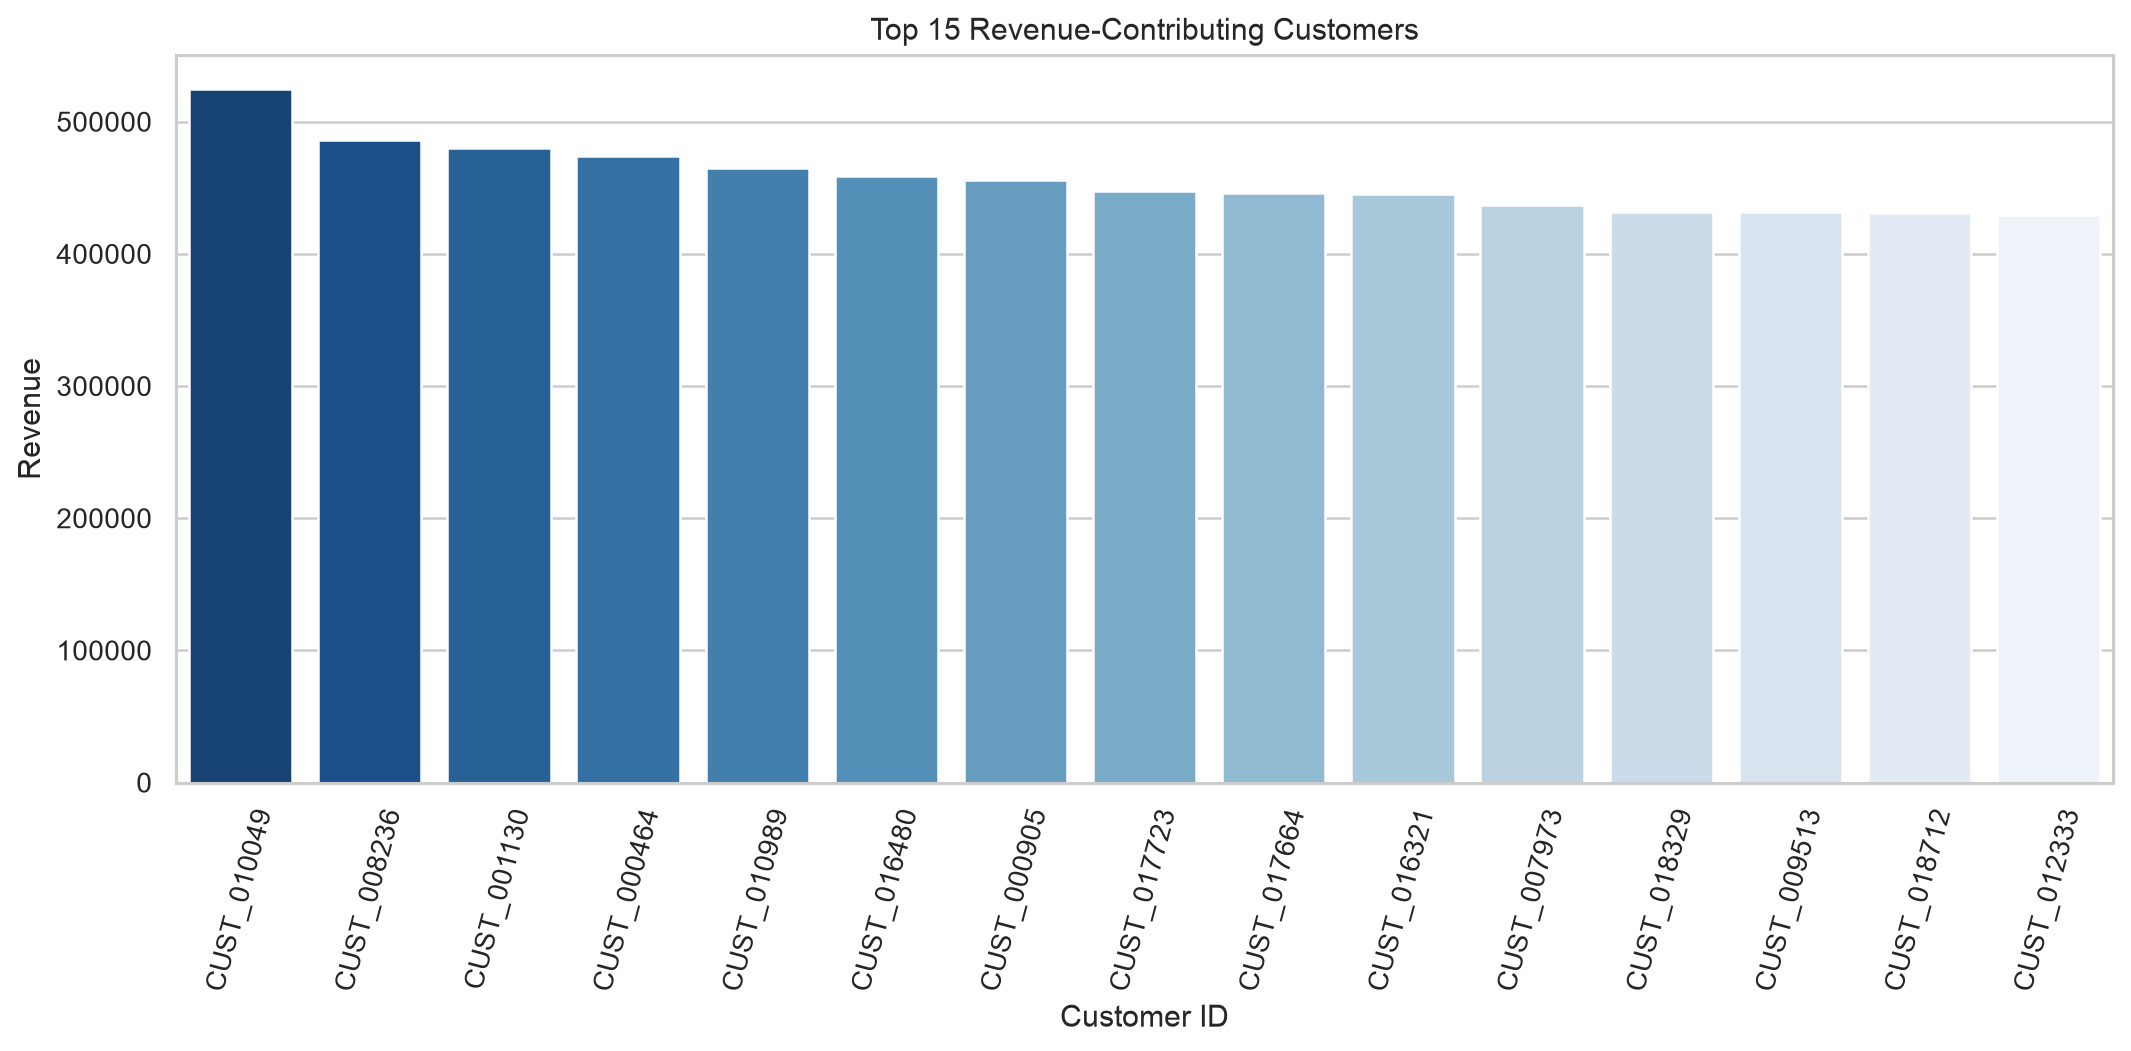

Business insight: a relatively small set of customers contributes a disproportionate share of revenue.


In [14]:
top_revenue_customers = customer_profitability.nlargest(20, "customer_revenue")
print(top_revenue_customers[["customer_id", "customer_revenue", "customer_profit"]].head(10).to_string(index=False))

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.barplot(data=top_revenue_customers.head(15), x="customer_id", y="customer_revenue", palette="Blues_r", ax=ax)
ax.set_title("Top 15 Revenue-Contributing Customers")
ax.set_xlabel("Customer ID")
ax.set_ylabel("Revenue")
ax.tick_params(axis="x", rotation=75)

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "top_revenue_contributors.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: a relatively small set of customers contributes a disproportionate share of revenue.")

## Top Profit Contributors

Top customers by profit are identified and exported for strategic account management.

customer_id  customer_profit  customer_revenue
CUST_010049        446375.32         524421.10
CUST_000464        429864.43         474199.20
CUST_001130        426679.75         480131.02
CUST_016480        413022.85         459007.28
CUST_010989        412756.15         465373.52
CUST_008236        404932.13         486487.60
CUST_016321        397431.81         445122.96
CUST_017723        394971.31         447915.48
CUST_018329        386530.70         431457.13
CUST_007973        381750.86         437256.07


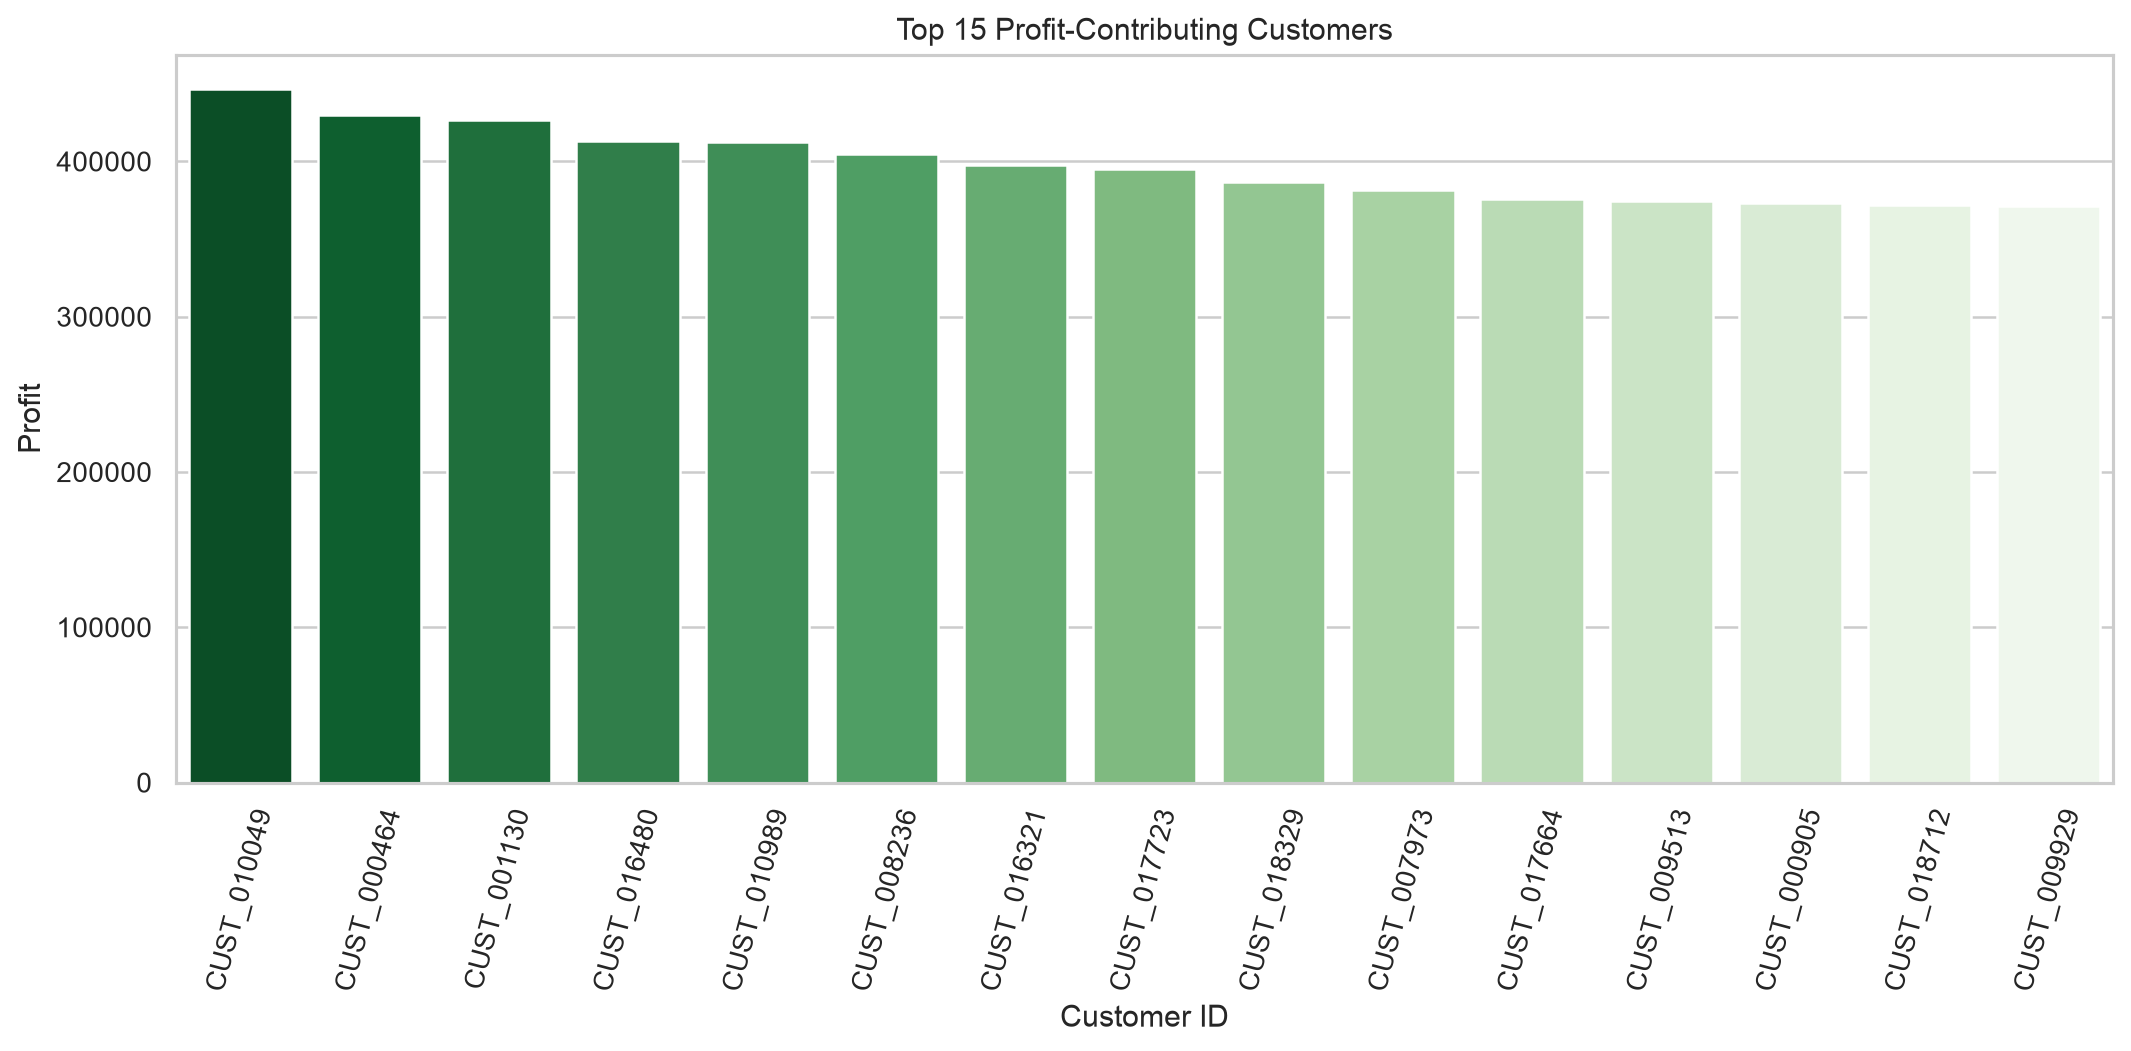

Business insight: high-profit customers are priority accounts for retention and upsell programs.


In [15]:
top_profit_customers = customer_profitability.nlargest(20, "customer_profit")
top_profit_customers.to_csv(OUTPUT_DIR / "top_profit_customers.csv", index=False)
print(top_profit_customers[["customer_id", "customer_profit", "customer_revenue"]].head(10).to_string(index=False))

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.barplot(data=top_profit_customers.head(15), x="customer_id", y="customer_profit", palette="Greens_r", ax=ax)
ax.set_title("Top 15 Profit-Contributing Customers")
ax.set_xlabel("Customer ID")
ax.set_ylabel("Profit")
ax.tick_params(axis="x", rotation=75)

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "top_profit_contributors.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: high-profit customers are priority accounts for retention and upsell programs.")

## Low Profit / Loss Making Customers

Customers with the lowest or negative profitability are highlighted for risk mitigation.

customer_id  customer_profit  customer_revenue  customer_cost
CUST_005045            36.74            203.27         166.53
CUST_004019            40.01            350.93         327.75
CUST_011627            57.43            339.07         332.39
CUST_007605            57.54            231.88         191.15
CUST_012620            64.01            446.77         405.01
CUST_014306            64.21            307.45         280.30
CUST_003058            70.19            383.70         364.76
CUST_011858            70.95            267.08         196.13
CUST_000361            73.23            385.55         349.09
CUST_010672            81.33            323.00         265.81
Loss-making customer count: 0


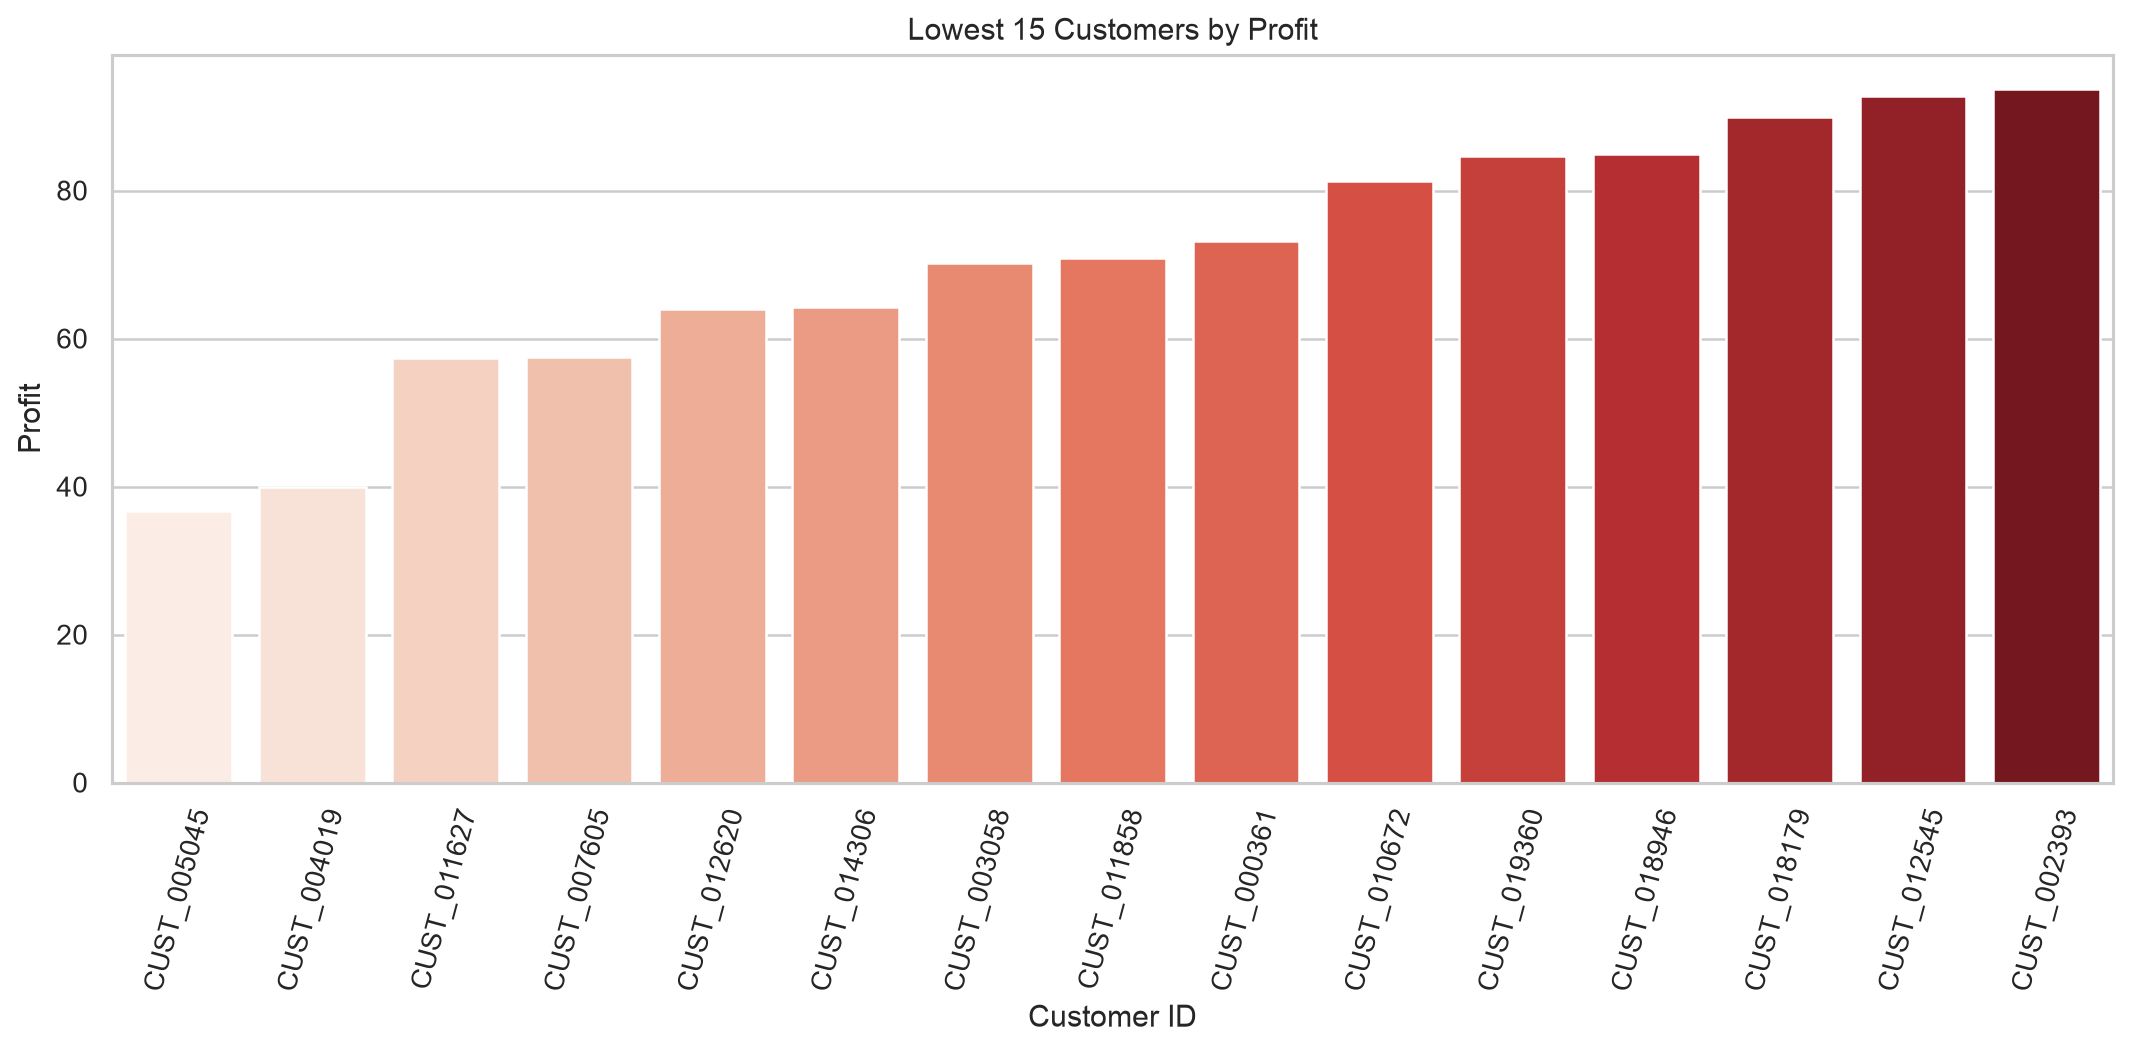

Business insight: sustained negative-profit customers require pricing, service-level, or cost-to-serve interventions.


In [16]:
low_profit_customers = customer_profitability.nsmallest(20, "customer_profit")
loss_customers = customer_profitability[customer_profitability["customer_profit"] < 0].copy()
print(low_profit_customers[["customer_id", "customer_profit", "customer_revenue", "customer_cost"]].head(10).to_string(index=False))
print("Loss-making customer count:", len(loss_customers))

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.barplot(data=low_profit_customers.head(15), x="customer_id", y="customer_profit", palette="Reds", ax=ax)
ax.set_title("Lowest 15 Customers by Profit")
ax.set_xlabel("Customer ID")
ax.set_ylabel("Profit")
ax.tick_params(axis="x", rotation=75)

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "low_profit_customers.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: sustained negative-profit customers require pricing, service-level, or cost-to-serve interventions.")

## Pareto (80-20) Analysis

This section evaluates how much revenue is contributed by the top customer cohort.

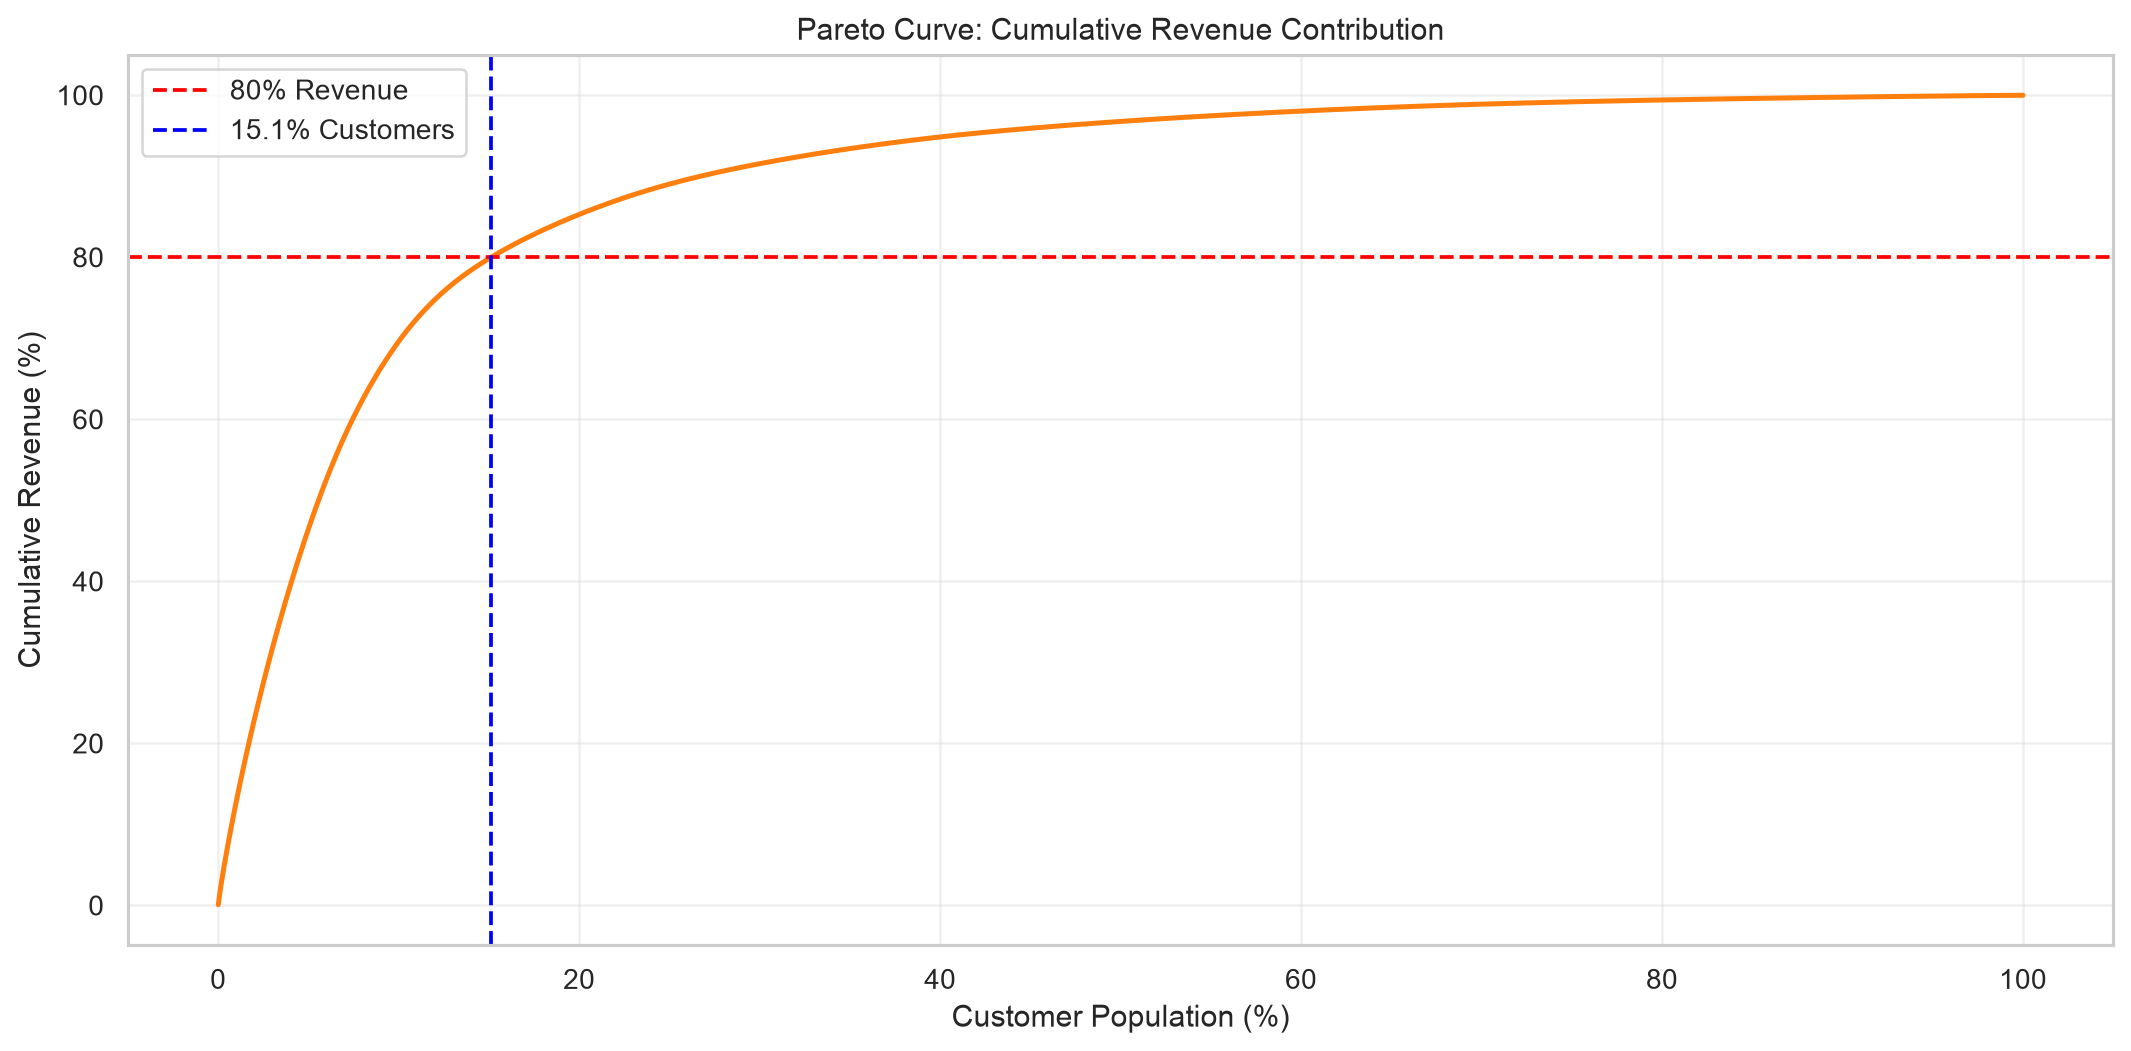

Business insight: approximately 15.1% of customers generate 80% of revenue.


In [17]:
pareto_df = customer_profitability[["customer_id", "customer_revenue"]].sort_values("customer_revenue", ascending=False).reset_index(drop=True)
pareto_df["cum_revenue"] = pareto_df["customer_revenue"].cumsum()
pareto_df["cum_revenue_pct"] = pareto_df["cum_revenue"] / pareto_df["customer_revenue"].sum()
pareto_df["customer_rank_pct"] = (pareto_df.index + 1) / len(pareto_df)

customers_for_80 = pareto_df.loc[pareto_df["cum_revenue_pct"] >= 0.8, "customer_rank_pct"].iloc[0]

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
ax.plot(pareto_df["customer_rank_pct"] * 100, pareto_df["cum_revenue_pct"] * 100, color="#ff7f0e", linewidth=2)
ax.axhline(80, color="red", linestyle="--", label="80% Revenue")
ax.axvline(customers_for_80 * 100, color="blue", linestyle="--", label=f"{customers_for_80*100:.1f}% Customers")
ax.set_title("Pareto Curve: Cumulative Revenue Contribution")
ax.set_xlabel("Customer Population (%)")
ax.set_ylabel("Cumulative Revenue (%)")
ax.legend()
ax.grid(True, alpha=0.3)

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "pareto_revenue_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print(f"Business insight: approximately {customers_for_80*100:.1f}% of customers generate 80% of revenue.")

## Revenue Concentration Analysis

Revenue concentration metrics summarize dependency on top customers.

In [18]:
top_10_share = top_revenue_customers.head(10)["customer_revenue"].sum() / customer_profitability["customer_revenue"].sum()
top_50_share = customer_profitability.nlargest(50, "customer_revenue")["customer_revenue"].sum() / customer_profitability["customer_revenue"].sum()

concentration_df = pd.DataFrame(
    {
        "metric": ["top_10_revenue_share", "top_50_revenue_share"],
        "value": [top_10_share, top_50_share],
    }
)
print(concentration_df.to_string(index=False))

              metric    value
top_10_revenue_share 0.008833
top_50_revenue_share 0.038404


## Profitability Trend Analysis

Monthly trends of revenue, profit, and margin are analyzed from transaction history.

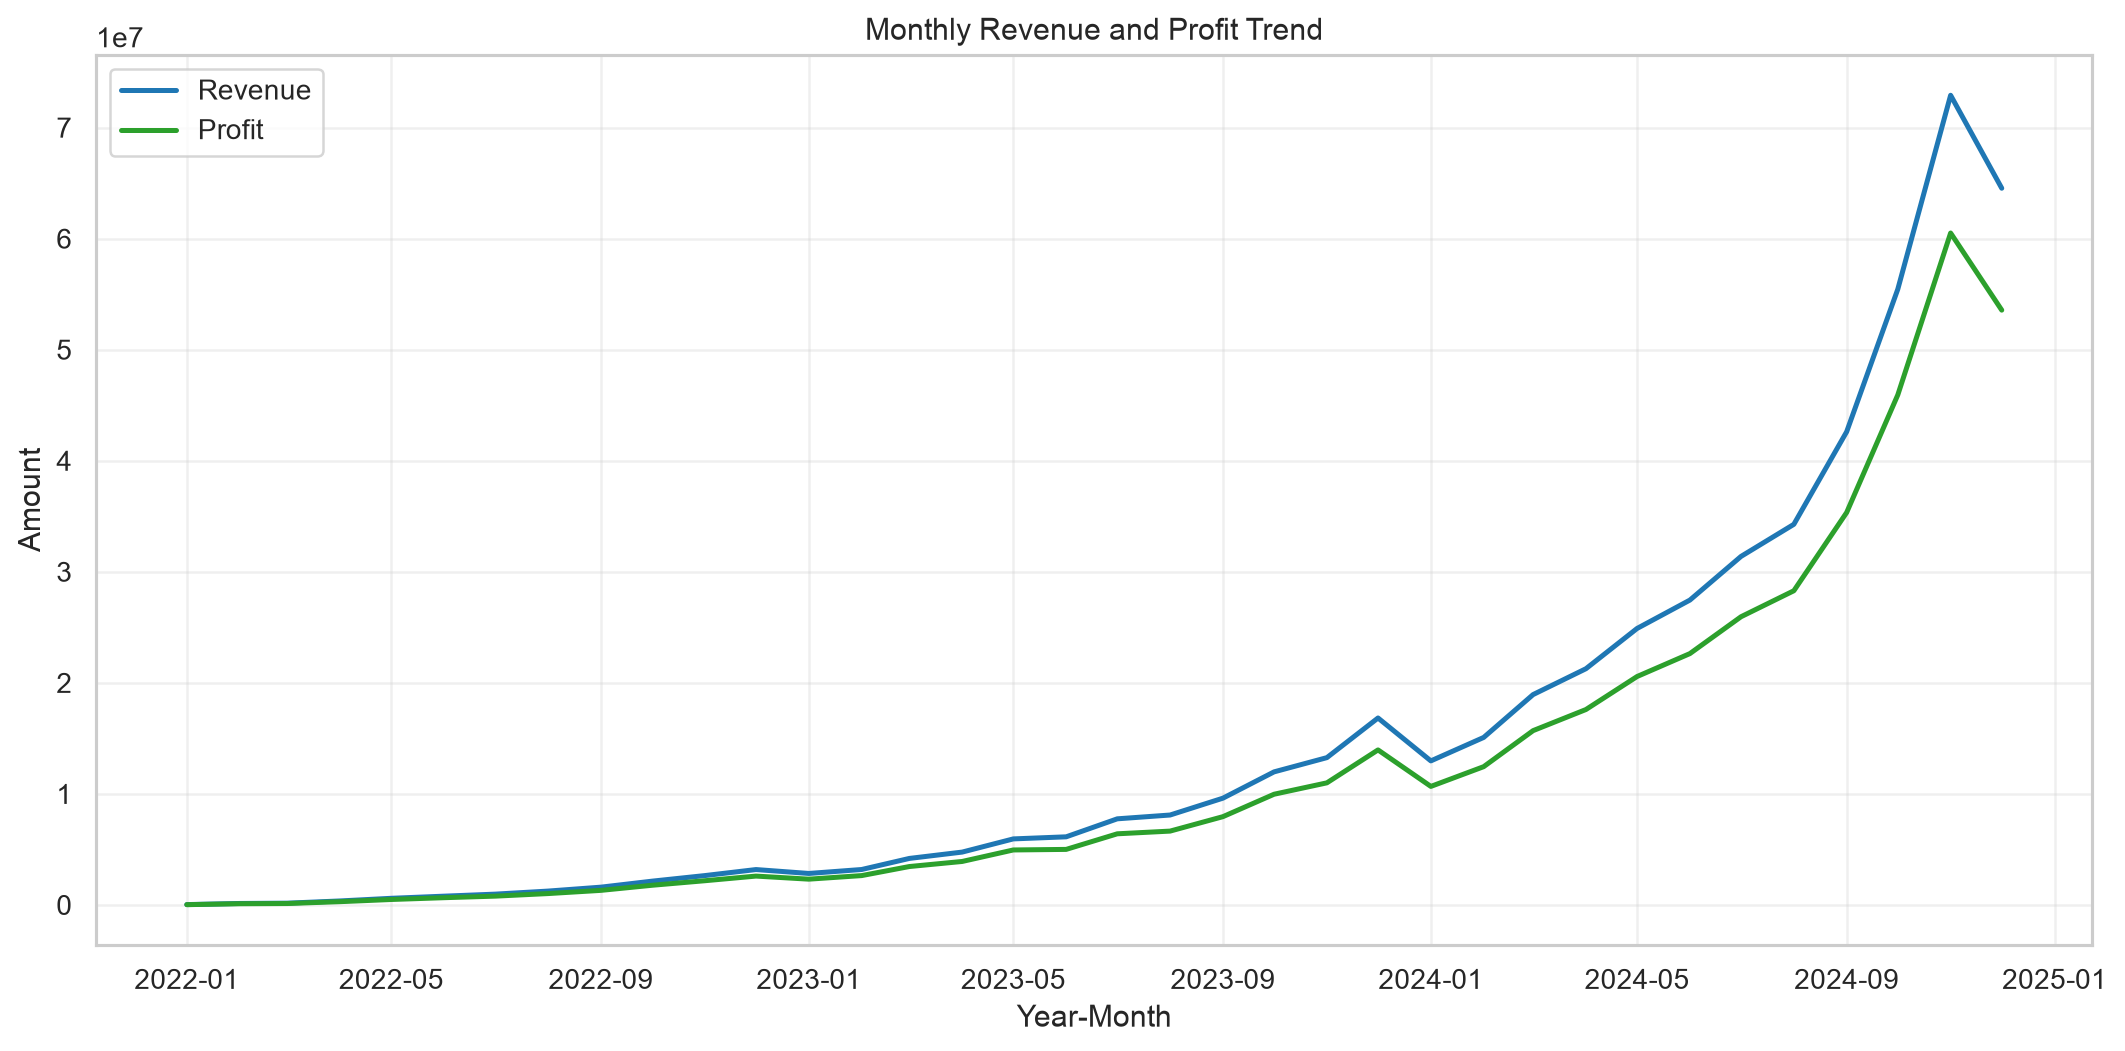

Business insight: tracking the gap between revenue and profit over time reveals margin pressure periods.


In [19]:
transactions_prepared["year_month"] = transactions_prepared["transaction_date"].dt.to_period("M").dt.to_timestamp()
trend_df = (
    transactions_prepared.groupby("year_month", as_index=False)
    .agg(total_revenue=("net_revenue", "sum"), total_profit=("profit", "sum"))
)
trend_df["profit_margin"] = safe_divide(trend_df["total_profit"], trend_df["total_revenue"])

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
ax.plot(trend_df["year_month"], trend_df["total_revenue"], label="Revenue", linewidth=2, color="#1f77b4")
ax.plot(trend_df["year_month"], trend_df["total_profit"], label="Profit", linewidth=2, color="#2ca02c")
ax.set_title("Monthly Revenue and Profit Trend")
ax.set_xlabel("Year-Month")
ax.set_ylabel("Amount")
ax.legend()
ax.grid(True, alpha=0.3)

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "profitability_trend.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: tracking the gap between revenue and profit over time reveals margin pressure periods.")

## Revenue vs Profit Scatter Analysis

Scatter analysis highlights account-level relationship between revenue and profit.

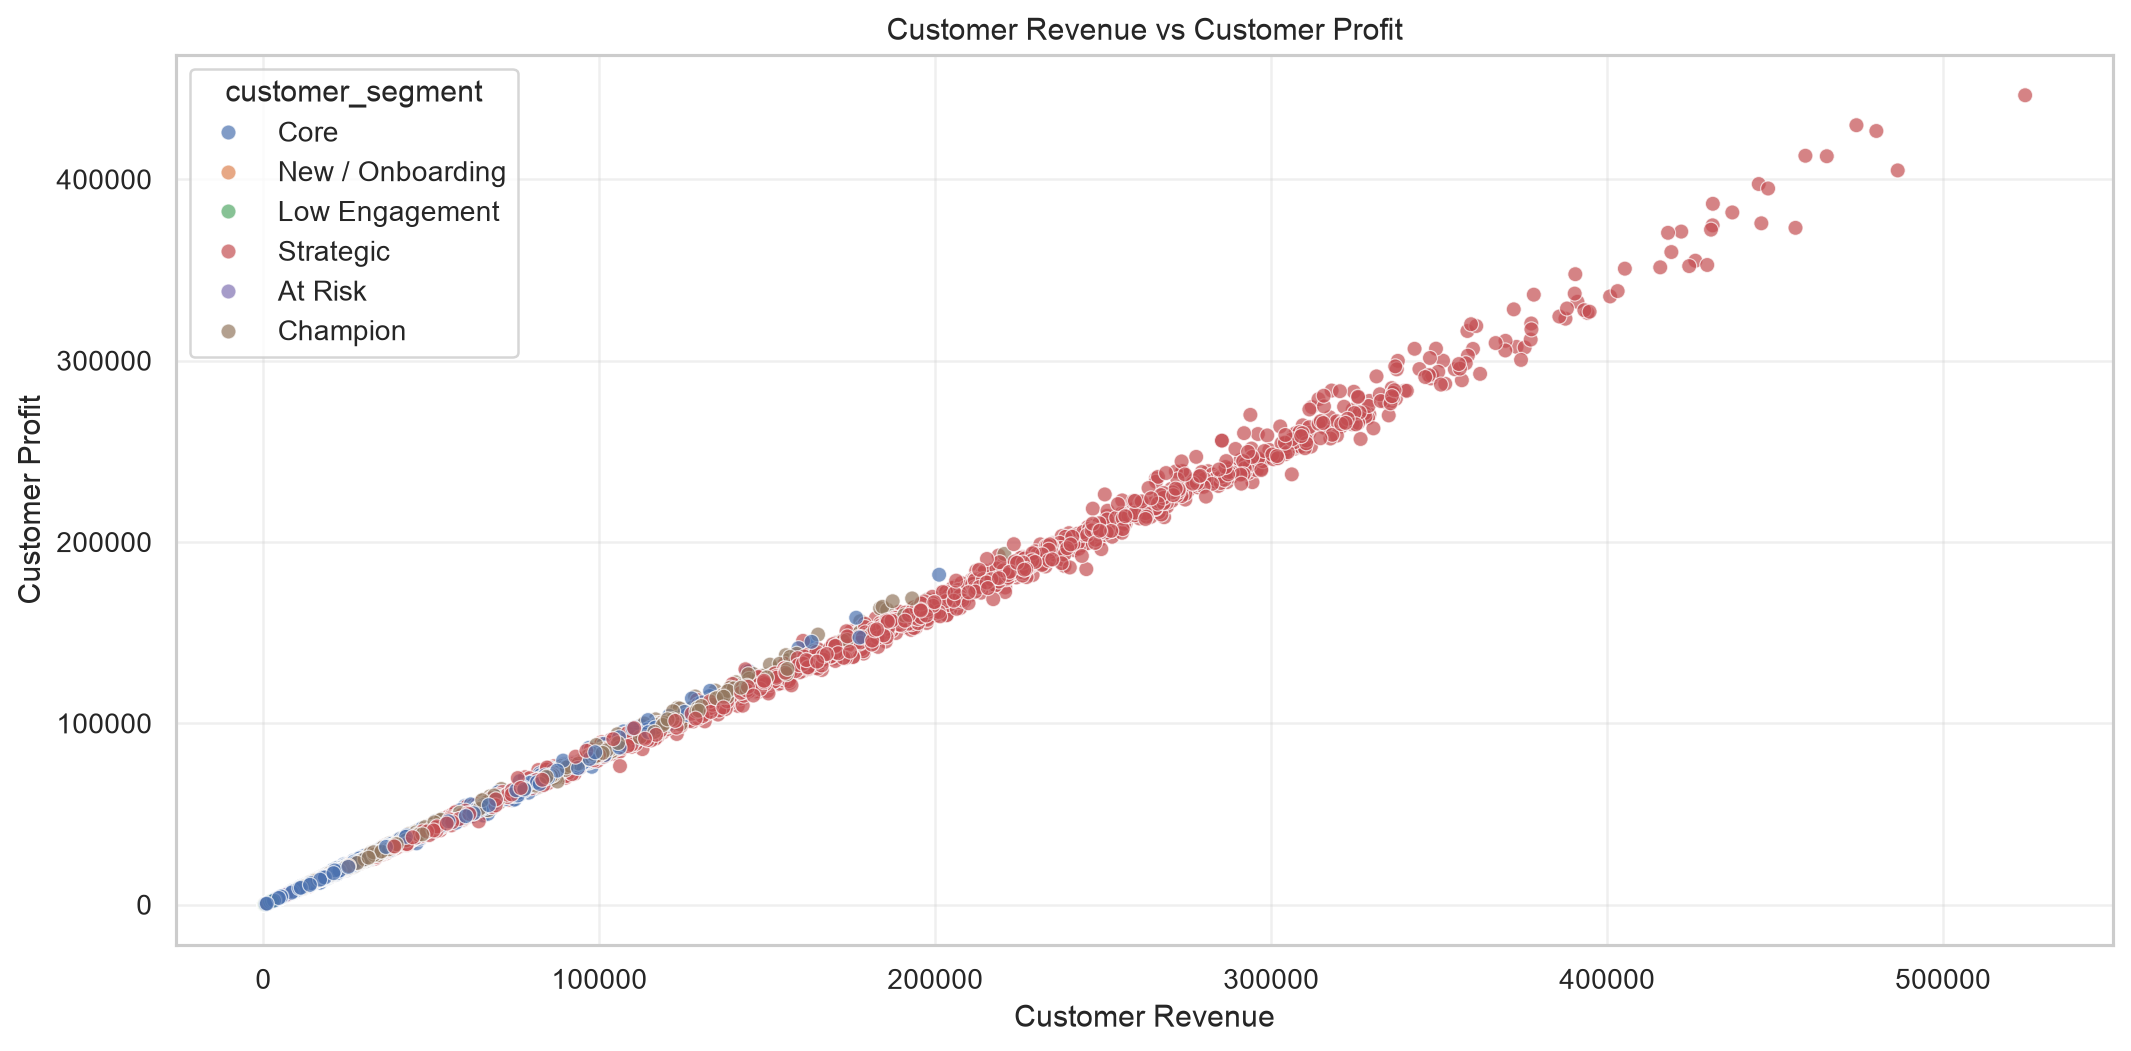

Business insight: customers with high revenue but low profit are candidates for cost-to-serve optimization.


In [20]:
scatter_df = customer_profitability.copy()

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.scatterplot(
    data=scatter_df,
    x="customer_revenue",
    y="customer_profit",
    hue="customer_segment" if "customer_segment" in scatter_df.columns else None,
    alpha=0.7,
    ax=ax,
)
ax.set_title("Customer Revenue vs Customer Profit")
ax.set_xlabel("Customer Revenue")
ax.set_ylabel("Customer Profit")
ax.grid(True, alpha=0.3)

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "revenue_vs_profit_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: customers with high revenue but low profit are candidates for cost-to-serve optimization.")

## Profit Margin Distribution

This section examines margin variability across transactions.

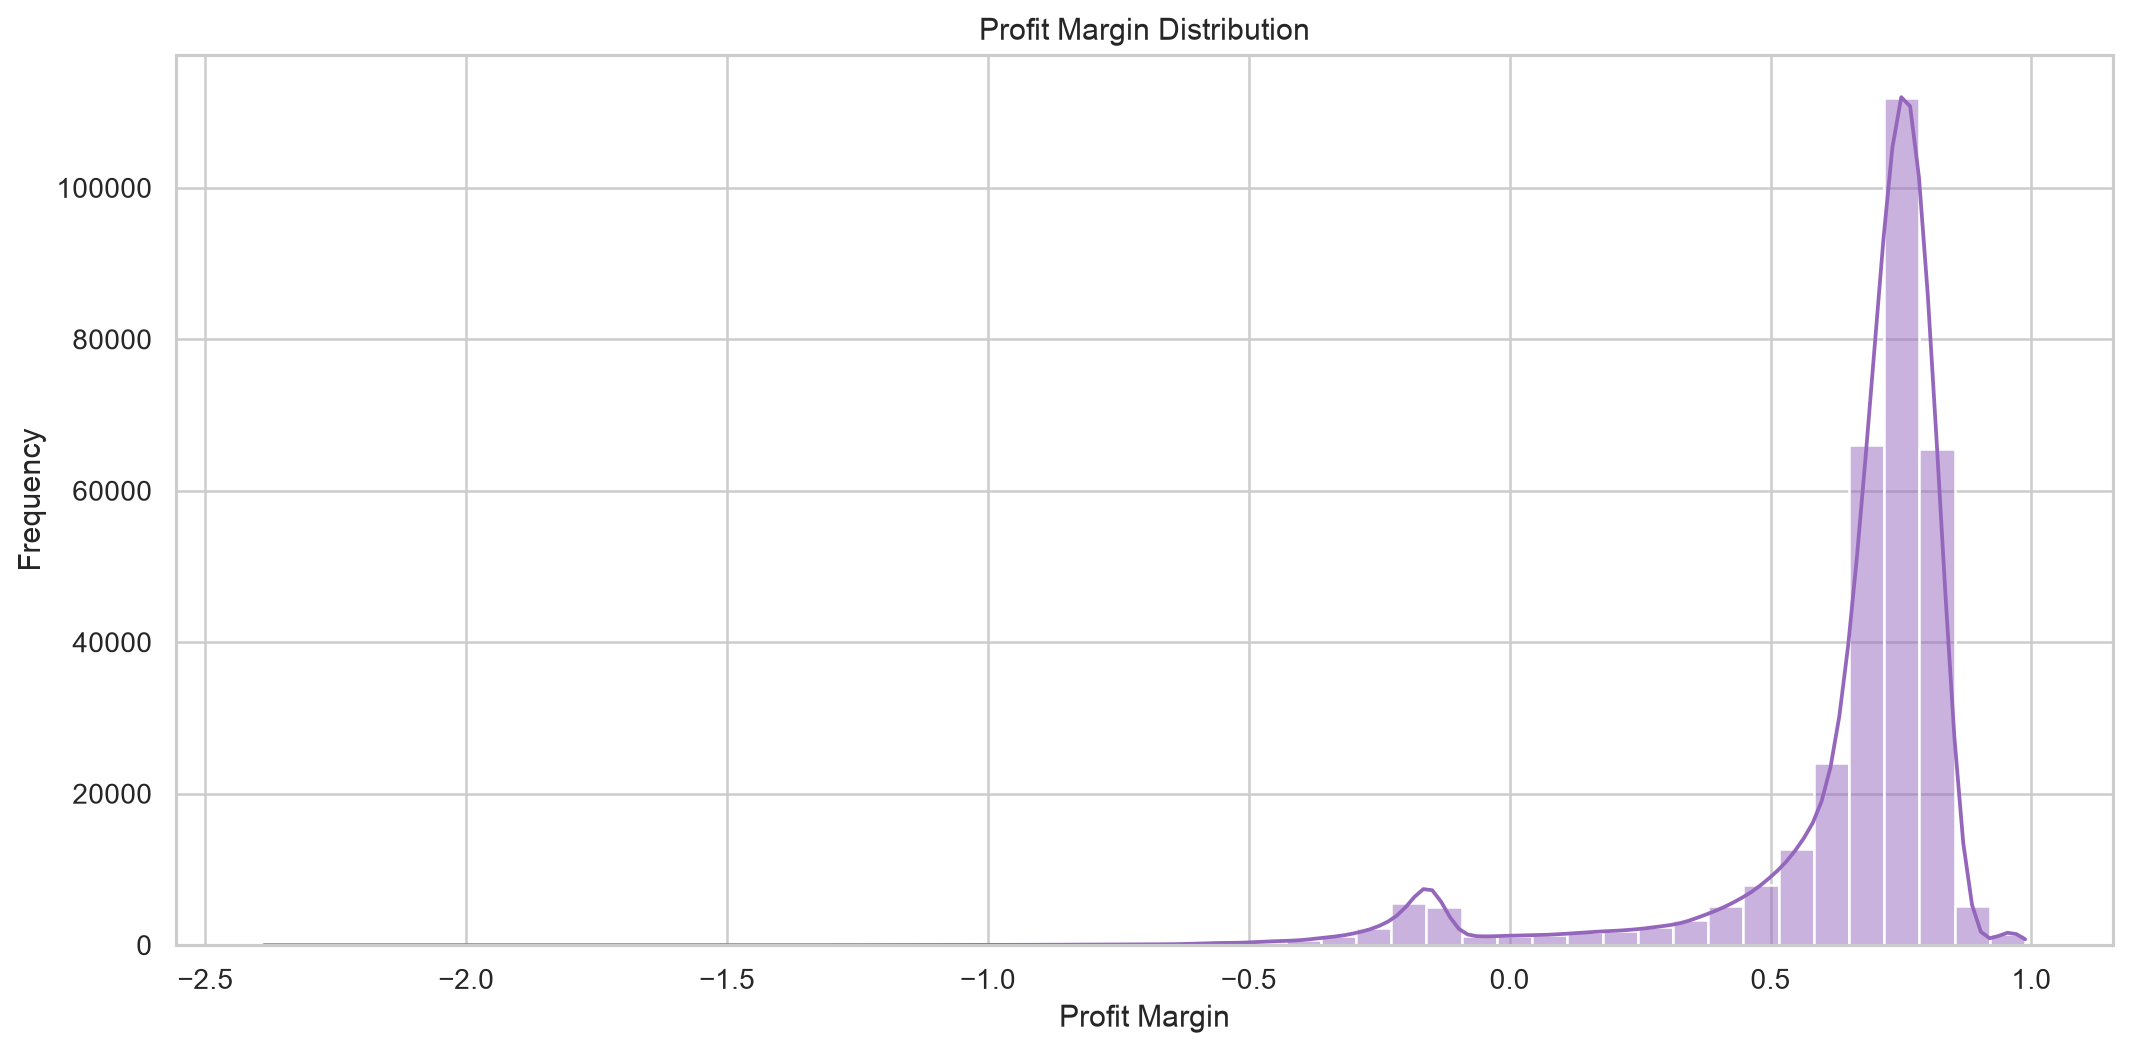

Business insight: wide margin dispersion indicates inconsistent unit economics across transaction types.


In [21]:
# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.histplot(transactions_prepared["profit_margin"], bins=50, kde=True, color="#9467bd", ax=ax)
ax.set_title("Profit Margin Distribution")
ax.set_xlabel("Profit Margin")
ax.set_ylabel("Frequency")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "profit_margin_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: wide margin dispersion indicates inconsistent unit economics across transaction types.")

## Waterfall Chart (if supported)

A simplified waterfall-style bridge from gross amount to net profit is built from aggregate totals.

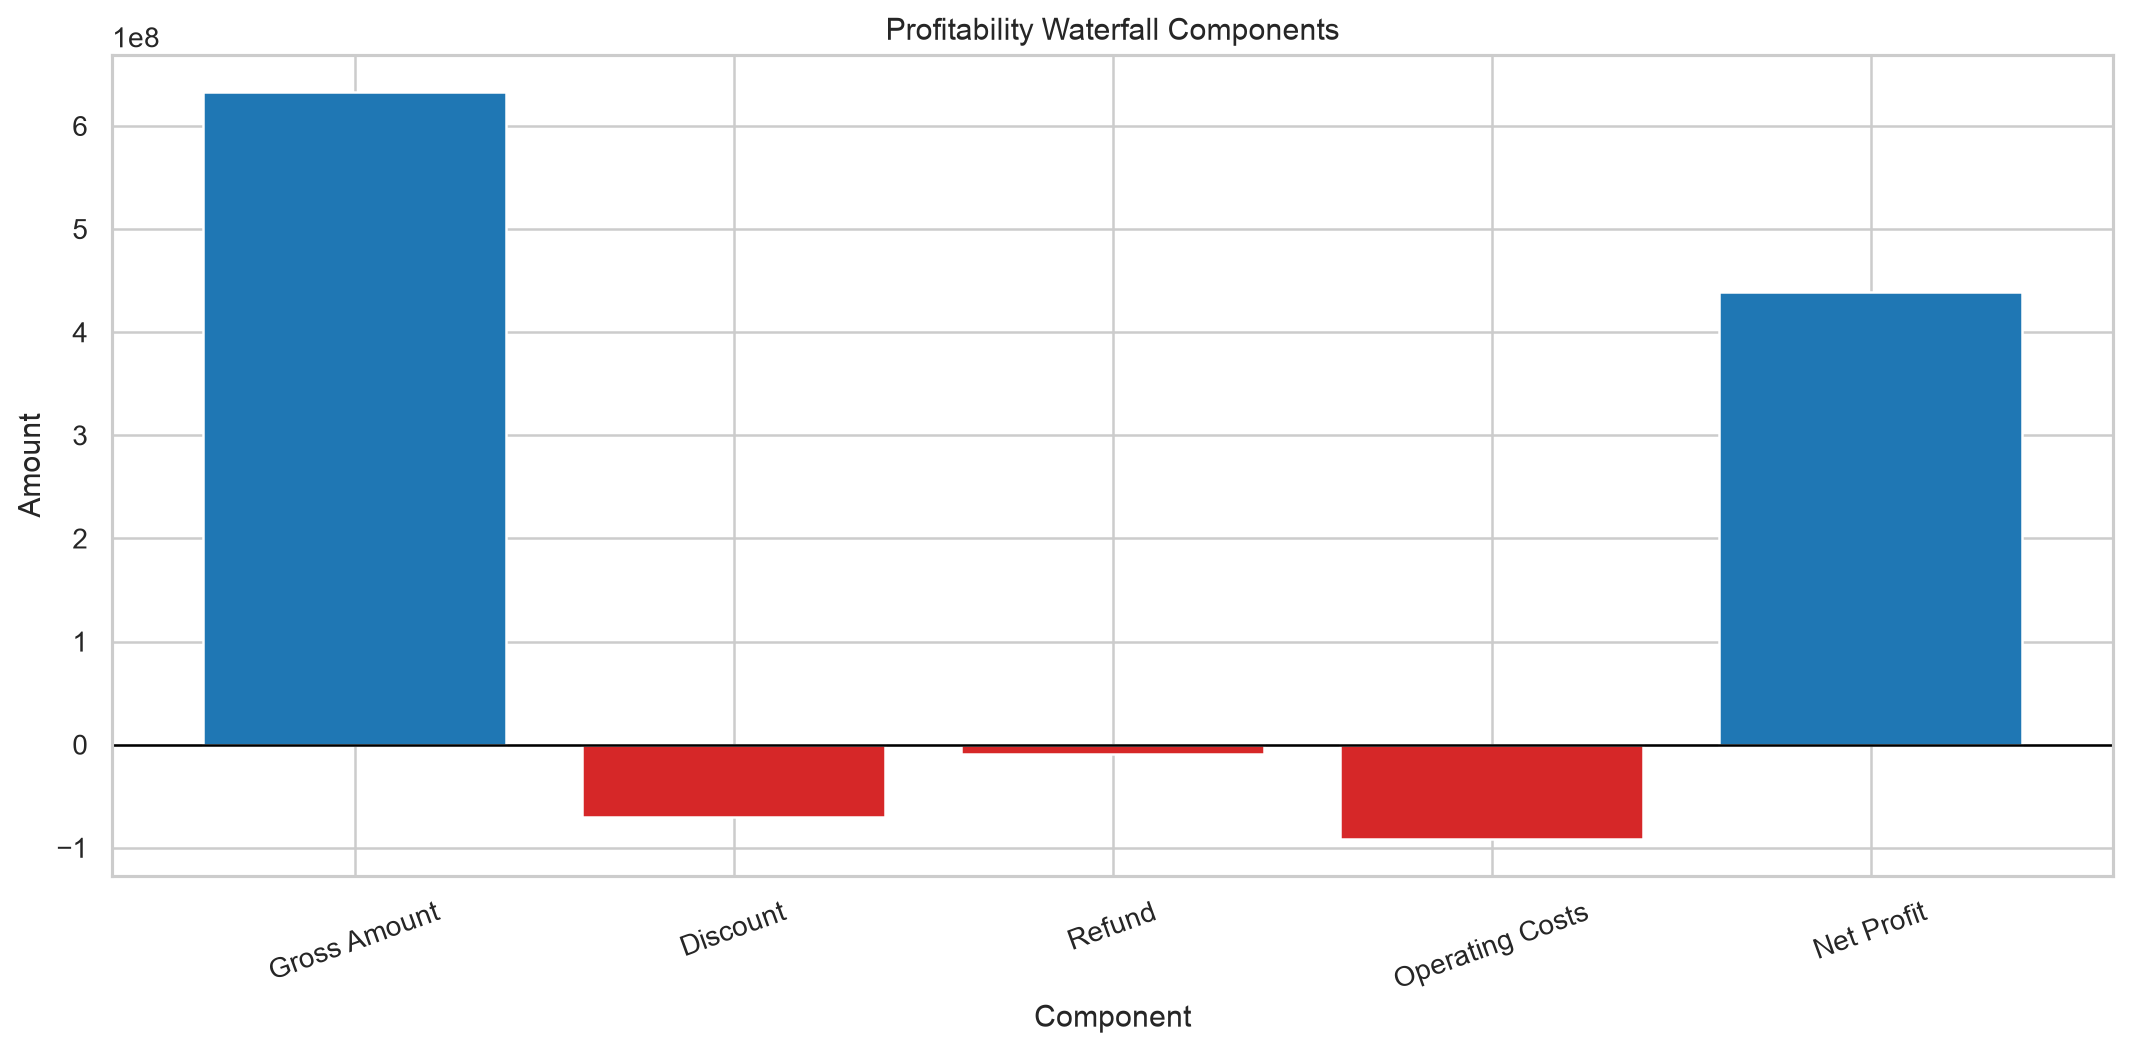

Business insight: the waterfall bridge highlights how discounts, refunds, and operating costs reduce gross value into final profit.


In [22]:
waterfall_values = {
    "Gross Amount": transactions_prepared["gross_amount"].sum() if "gross_amount" in transactions_prepared.columns else transactions_prepared["net_revenue"].sum(),
    "Discount": -transactions_prepared["discount"].sum() if "discount" in transactions_prepared.columns else 0,
    "Refund": -transactions_prepared["refund_amount"].sum(),
    "Operating Costs": -(transactions_prepared["support_cost"].sum() + transactions_prepared["marketing_cost"].sum() + transactions_prepared["operational_cost"].sum() + transactions_prepared["processing_fee"].sum()),
    "Net Profit": transactions_prepared["profit"].sum(),
}

wf_df = pd.DataFrame({"component": list(waterfall_values.keys()), "value": list(waterfall_values.values())})

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
colors = ["#1f77b4" if x >= 0 else "#d62728" for x in wf_df["value"]]
ax.bar(wf_df["component"], wf_df["value"], color=colors)
ax.set_title("Profitability Waterfall Components")
ax.set_xlabel("Component")
ax.set_ylabel("Amount")
ax.tick_params(axis="x", rotation=20)
ax.axhline(0, color="black", linewidth=1)

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "profitability_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: the waterfall bridge highlights how discounts, refunds, and operating costs reduce gross value into final profit.")

## Correlation Analysis

Correlation analysis is performed on numeric profitability-related columns.

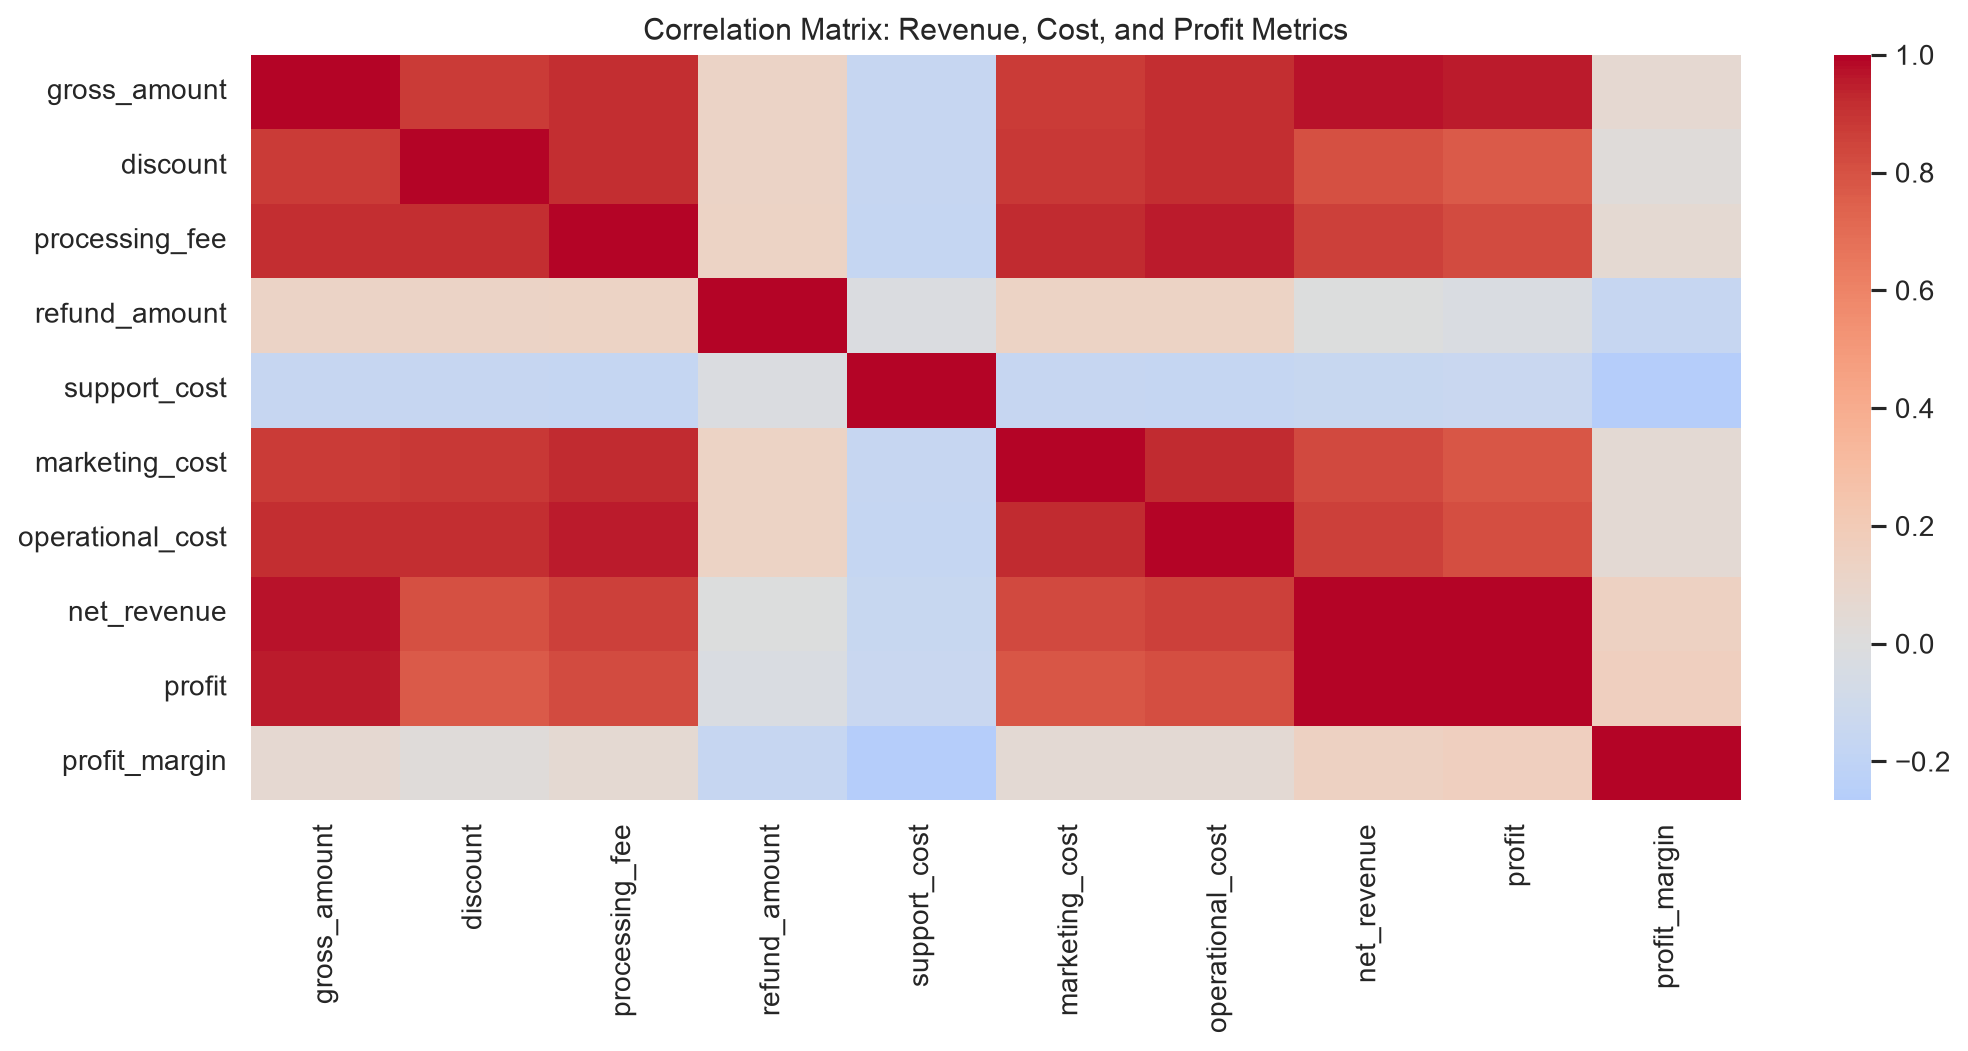

Business insight: correlation patterns reveal which cost drivers most strongly influence profit outcomes.


In [23]:
numeric_cols = [
    "gross_amount",
    "discount",
    "processing_fee",
    "refund_amount",
    "support_cost",
    "marketing_cost",
    "operational_cost",
    "net_revenue",
    "profit",
    "profit_margin",
]
existing_numeric_cols = [col for col in numeric_cols if col in transactions_prepared.columns]
corr_df = transactions_prepared[existing_numeric_cols].corr(numeric_only=True)

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.heatmap(corr_df, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Correlation Matrix: Revenue, Cost, and Profit Metrics")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "profitability_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

print("Business insight: correlation patterns reveal which cost drivers most strongly influence profit outcomes.")

## Business Insights

This section consolidates cross-cutting findings from the profitability analysis.

In [24]:
highest_revenue_category = product_profitability.iloc[0, 0] if not product_profitability.empty else "N/A"
highest_profit_category = product_profitability.sort_values("total_profit", ascending=False).iloc[0, 0] if not product_profitability.empty else "N/A"

insights = [
    f"Total analyzed revenue is {transactions_prepared['net_revenue'].sum():,.2f} with total profit {transactions_prepared['profit'].sum():,.2f}.",
    f"Revenue concentration remains high: top 10 customers contribute {top_10_share:.2%} of revenue.",
    f"Highest revenue category: {highest_revenue_category}; highest profit category: {highest_profit_category}.",
    f"Loss-making customers identified: {len(loss_customers)}.",
]

for item in insights:
    print(f"- {item}")

- Total analyzed revenue is 530,337,543.22 with total profit 438,885,098.31.
- Revenue concentration remains high: top 10 customers contribute 0.88% of revenue.
- Highest revenue category: Renewal; highest profit category: Renewal.
- Loss-making customers identified: 0.


## Executive Profitability Summary

This section provides the required executive summary metrics and strategic interpretation.

In [25]:
most_profitable_customers = top_profit_customers["customer_id"].head(5).tolist()
least_profitable_customers = low_profit_customers["customer_id"].head(5).tolist()

executive_summary = pd.DataFrame(
    {
        "metric": [
            "Total Revenue",
            "Total Profit",
            "Average Profit Margin",
            "Highest Revenue Category",
            "Highest Profit Category",
            "Most Profitable Customers",
            "Least Profitable Customers",
            "Revenue Concentration",
            "Business Risks",
            "Growth Opportunities",
        ],
        "value": [
            round(float(transactions_prepared["net_revenue"].sum()), 2),
            round(float(transactions_prepared["profit"].sum()), 2),
            round(float(transactions_prepared["profit_margin"].mean()), 4),
            highest_revenue_category,
            highest_profit_category,
            ", ".join(most_profitable_customers),
            ", ".join(least_profitable_customers),
            f"Top 10 customers contribute {top_10_share:.2%} of total revenue",
            "Margin compression from high operating/marketing cost and refund concentration in low-profit cohorts",
            "Improve pricing, reduce cost-to-serve for loss-making accounts, and expand high-margin categories/channels",
        ],
    }
)

print(executive_summary.to_string(index=False))

                    metric                                                                                                      value
             Total Revenue                                                                                               530337543.22
              Total Profit                                                                                               438885098.31
     Average Profit Margin                                                                                                     0.6544
  Highest Revenue Category                                                                                                    Renewal
   Highest Profit Category                                                                                                    Renewal
 Most Profitable Customers                                            CUST_010049, CUST_000464, CUST_001130, CUST_016480, CUST_010989
Least Profitable Customers                                    

## Save Outputs

All required output tables are exported to `outputs/`.

In [26]:
# Required exports
profitability_summary.to_csv(OUTPUT_DIR / "profitability_summary.csv", index=False)
customer_profitability.to_csv(OUTPUT_DIR / "customer_profitability.csv", index=False)
product_profitability.to_csv(OUTPUT_DIR / "product_profitability.csv", index=False)
revenue_analysis.to_csv(OUTPUT_DIR / "revenue_analysis.csv", index=False)
top_profit_customers.to_csv(OUTPUT_DIR / "top_profit_customers.csv", index=False)
executive_summary.to_csv(OUTPUT_DIR / "executive_profitability_summary.csv", index=False)

print("Saved:")
print("-", OUTPUT_DIR / "profitability_summary.csv")
print("-", OUTPUT_DIR / "customer_profitability.csv")
print("-", OUTPUT_DIR / "product_profitability.csv")
print("-", OUTPUT_DIR / "revenue_analysis.csv")
print("-", OUTPUT_DIR / "top_profit_customers.csv")
print("-", OUTPUT_DIR / "executive_profitability_summary.csv")
print("Profitability notebook completed successfully.")

Saved:
- /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/profitability_summary.csv
- /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/customer_profitability.csv
- /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/product_profitability.csv
- /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/revenue_analysis.csv
- /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/top_profit_customers.csv
- /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/executive_profitability_summary.csv
Profitability notebook completed successfully.
